# Proyek Akhir

Kelompok 07
- Andrea Verlina (222200103/IBDA)
- Brygitta Josefien (222102260/IBDA)
- Elaine Evelyn (222102311/IBDA)

## Penjelasan Masalah dan Data
Masalah yang kami temukan adalah sulitnya melakukan penelitian tentang bintang, terutama dalam menentukan tahapan kehidupan bintang, jika kita hanya memiliki kumpulan data besar yang tidak terorganisir. Data bintang yang tidak terorganisir tidak memiliki kategorisasi, sehingga bisa dikatakan tidak ada artinya. Tanpa klasifikasi yang tepat, kita tidak dapat menarik kesimpulan atau wawasan yang berarti dari data. Hal ini menghambat kemampuan kita untuk menganalisis dan menafsirkan perilaku dan karakteristik bintang secara akurat, seperti mempelajari tahapan kehidupan mereka, bagaimana mereka terbentuk, berevolusi, dan akhirnya mati. Oleh karena itu, mengatur dan mengkategorikan data bintang menjadi raksasa (Giants) dan katai (Dwarfs) sangat penting untuk memajukan penelitian bintang.

Dalam proyek ini, kami akan melatih berbagai model agar mampu mengklasifikasi tipe bintang menjadi Giants dan Dwarfs berdasarkan karakteristik fisiknya seperti magnitude of star (tingkat kecerahan absolut bintang), B-V color index (memberikan petunjuk tentang suhu bintang), visual apparent magnitude (magnitudo bintang seperti terlihat dari Bumi), dan spectral type (memberikan petunjuk tentang suhu dan komposisi kimia bintang).

Data yang digunakan dalam proyek ini berasal dari Kaggle (https://www.kaggle.com/datasets/vinesmsuic/star-categorization-giants-and-dwarfs/data). Dataset ini berisi 99999 data raw (tanpa preprocessing data) tentang magnitude of star, B-V color index, visual apparent magnitude, dan stellar parallax.

## Preparation

In [58]:
# Mengimpor libraries
import pandas as pd  # pandas is a data manipulation library. It's used for creating and manipulating dataframes.
import numpy as np  # numpy is a library for numerical computations in Python.
import seaborn as sns  # seaborn is a data visualization library based on matplotlib.
import matplotlib.pyplot as plt  # matplotlib is a plotting library. plt is a module in matplotlib used for plotting.
from sklearn.model_selection import train_test_split  # This function is used to split the dataset into training and testing datasets.
from sklearn.preprocessing import StandardScaler   # This is used to scale the data.
from sklearn.linear_model import LogisticRegression  # Logistic Regression is a machine learning algorithm for classification.
from sklearn.naive_bayes import GaussianNB  # Gaussian Naive Bayes is a machine learning algorithm for classification.
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors (KNN) is a machine learning algorithm for classification.
from sklearn.svm import SVC  # Support Vector Machines (SVM) is a machine learning algorithm for classification.
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron classifier is a machine learning algorithm for classification.
from sklearn.tree import DecisionTreeClassifier  # Decision Tree is a machine learning algorithm for classification.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # These are machine learning algorithms for classification.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # These functions are used to measure the performance of the classification models.
from sklearn.model_selection import GridSearchCV  # This is used to find the best hyperparameters for the model.
from sklearn.metrics import precision_score, recall_score, f1_score # These functions are used to measure the performance of the classification models.
from sklearn.model_selection import cross_val_score # This is used to evaluate the model using cross-validation.
from matplotlib.font_manager import FontProperties
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
import warnings 
warnings.filterwarnings('ignore')  # This is used to ignore warnings.

In [59]:
# Mengimpor dataset
df = pd.read_csv('Star99999_raw.csv')  # Reading a CSV file and storing the data in a pandas DataFrame called 'df'.
display(df)  # Displaying the DataFrame 'train_df'. It's similar to print, but for pandas DataFrames, it can provide a more visually appealing output.

,Unnamed: 0,Vmag,Plx,e_Plx,B-V,SpType
0,0,9.10,3.54,1.39,0.482,F5
1,1,9.27,21.90,3.10,0.999,K3V
2,2,6.61,2.81,0.63,-0.019,B9
3,3,8.06,7.75,0.97,0.370,F0V
4,4,8.55,2.87,1.11,0.902,G8III
...,...,...,...,...,...,...
99994,99994,8.72,3.07,0.87,0.097,B3
99995,99995,9.25,,,0.131,A1V
99996,99996,8.08,1.07,0.68,1.094,G5
99997,99997,6.98,2.97,0.76,-0.143,B1.5V


In [60]:
df = df.drop(['Unnamed: 0'], axis=1)  # Menghapus kolom 'Unnamed: 0' dari DataFrame 'df'.

In [61]:
df.info()  # Printing information about the DataFrame 'train_df'. It provides a concise summary of the DataFrame.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Vmag    99999 non-null  object
 1   Plx     99999 non-null  object
 2   e_Plx   99999 non-null  object
 3   B-V     99999 non-null  object
 4   SpType  97377 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


Vmag         0
Plx          0
e_Plx        0
B-V          0
SpType    2622
dtype: int64

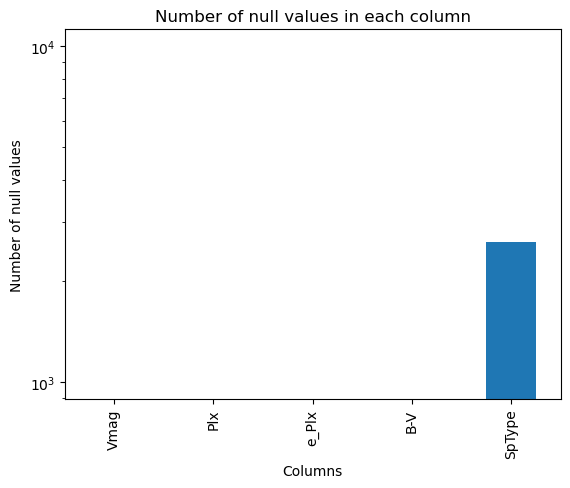

In [62]:
# Check if there are any null values in the train dataset
display(df.isnull().sum())

# Calculate the sum of null values in each column
null_values = df.isnull().sum()

# Create a bar chart
null_values.plot(kind='bar')

# Set the title and labels
plt.title('Number of null values in each column')
plt.xlabel('Columns')
plt.ylabel('Number of null values')

# Set the y-axis to a logarithmic scale
plt.yscale('log')

# Display the plot
plt.show()


In [63]:
df.nunique()

Vmag      1110
Plx       5331
e_Plx     1282
B-V       2392
SpType    3756
dtype: int64

## Pre-Processing (Cleaning Data, Data Transformation, Data Reduction(Balancing Data))

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Vmag    99999 non-null  object
 1   Plx     99999 non-null  object
 2   e_Plx   99999 non-null  object
 3   B-V     99999 non-null  object
 4   SpType  97377 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


In [65]:
df.describe()

,Vmag,Plx,e_Plx,B-V,SpType
count,99999,99999,99999,99999,97377
unique,1110,5331,1282,2392,3756
top,8.40,,0.91,,K0
freq,426,231,1216,1128,7355


In [66]:
# Convert Columns data type to float values
df["Vmag"] = pd.to_numeric(df["Vmag"], downcast="float", errors='coerce')
df["Plx"] = pd.to_numeric(df["Plx"], downcast="float", errors='coerce')
df["e_Plx"] = pd.to_numeric(df["e_Plx"], downcast="float", errors='coerce')
df["B-V"] = pd.to_numeric(df["B-V"], downcast="float", errors='coerce')

In [67]:
# Check the DataType of our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Vmag    99998 non-null  float32
 1   Plx     99768 non-null  float32
 2   e_Plx   99768 non-null  float32
 3   B-V     98871 non-null  float32
 4   SpType  97377 non-null  object 
dtypes: float32(4), object(1)
memory usage: 2.3+ MB


In [68]:
# Show all the columns, add parameter `include='all'`.
df.describe(include='all')

,Vmag,Plx,e_Plx,B-V,SpType
count,99998.000000,99768.000000,99768.000000,98871.000000,97377
unique,NaN,NaN,NaN,NaN,3756
top,NaN,NaN,NaN,NaN,K0
freq,NaN,NaN,NaN,NaN,7355
mean,8.369723,7.212443,1.365389,0.704728,NaN
std,1.313896,11.348988,1.816838,0.489679,NaN
min,-1.440000,-54.950001,0.380000,-0.400000,NaN
25%,7.640000,2.510000,0.880000,0.348000,NaN
50%,8.440000,4.630000,1.100000,0.612000,NaN
75%,9.140000,8.410000,1.390000,1.075000,NaN


### Checking Missing Data

In [69]:
# get the number of missing data points per column
missing_values_count = df.isnull().sum()
missing_values_count

Vmag         1
Plx        231
e_Plx      231
B-V       1128
SpType    2622
dtype: int64

In [70]:
# Ask how many total missing values do we have?
total_cells = np.product(df.shape)
total_missing = missing_values_count.sum()

# Count percentage of data that is missing
percent_missing = (total_missing/total_cells)
print("Percentage Missing:", "{:.2%}".format(percent_missing))

Percentage Missing: 0.84%


### Drop Rows With Missing Data

In [71]:
# remove all the rows that contain a missing value
# better to store it into a new variable to avoid confusion
df_dropped = df.dropna() 
df_dropped_reindex = df_dropped.reset_index(drop=True)
df_dropped_reindex

,Vmag,Plx,e_Plx,B-V,SpType
0,9.10,3.54,1.39,0.482,F5
1,9.27,21.90,3.10,0.999,K3V
2,6.61,2.81,0.63,-0.019,B9
3,8.06,7.75,0.97,0.370,F0V
4,8.55,2.87,1.11,0.902,G8III
...,...,...,...,...,...
96737,7.92,3.93,1.24,0.133,Am...
96738,8.72,3.07,0.87,0.097,B3
96739,8.08,1.07,0.68,1.094,G5
96740,6.98,2.97,0.76,-0.143,B1.5V


In [72]:
df_dropped = df_dropped_reindex

# Ask just how much rows did we drop?
dropped_rows_count = df.shape[0]-df_dropped.shape[0]
print("Rows we dropped from original dataset: %d " % dropped_rows_count)

# Percentage we dropped
percent_dropped = dropped_rows_count/df.shape[0]
print("Percentage Loss:", "{:.2%}".format(percent_dropped))

Rows we dropped from original dataset: 3257 
Percentage Loss: 3.26%


In [73]:
df_dropped.describe()
df = df_dropped

### Create Absolute Magnitude Collumn

$$
M = m - 5\log_{}\left(\frac{d}{10}\right)
$$
$$
M = m - 5\log_{}\left(\frac{100}{p}\right)
$$
𝑀 = absolute magnitude (Amag),  
𝑚 = visual apparent magnitude (Vmag),  
𝑝 = stellar parallax (Plx)

In [74]:
#Dropping rows that `Plx` = 0 because log 0 will be infinity
df = df[df["Plx"] > 0]

dispc = 1000 / df["Plx"] # Plx (mas)
df["Absmag"] = df.iloc[:, df.columns.get_loc("Vmag")] - 5 * np.log10(dispc / 10) # Absolute magnitude

df = df.reset_index(drop=True)
df

,Vmag,Plx,e_Plx,B-V,SpType,Absmag
0,9.10,3.54,1.39,0.482,F5,1.845016
1,9.27,21.90,3.10,0.999,K3V,5.972221
2,6.61,2.81,0.63,-0.019,B9,-1.146469
3,8.06,7.75,0.97,0.370,F0V,2.506509
4,8.55,2.87,1.11,0.902,G8III,0.839409
...,...,...,...,...,...,...
93551,7.69,6.60,0.92,1.110,K2III,1.787720
93552,7.92,3.93,1.24,0.133,Am...,0.891963
93553,8.72,3.07,0.87,0.097,B3,1.155692
93554,8.08,1.07,0.68,1.094,G5,-1.773081


In [75]:
Font1 = {"family": "Arial", "weight": "bold", "color": "red", "size": 18}
Font2 = {"family": "Arial", "weight": "bold", "color": "red", "size": 20}
Font3 = FontProperties(family="Arial", weight='bold', style='normal', size=19)

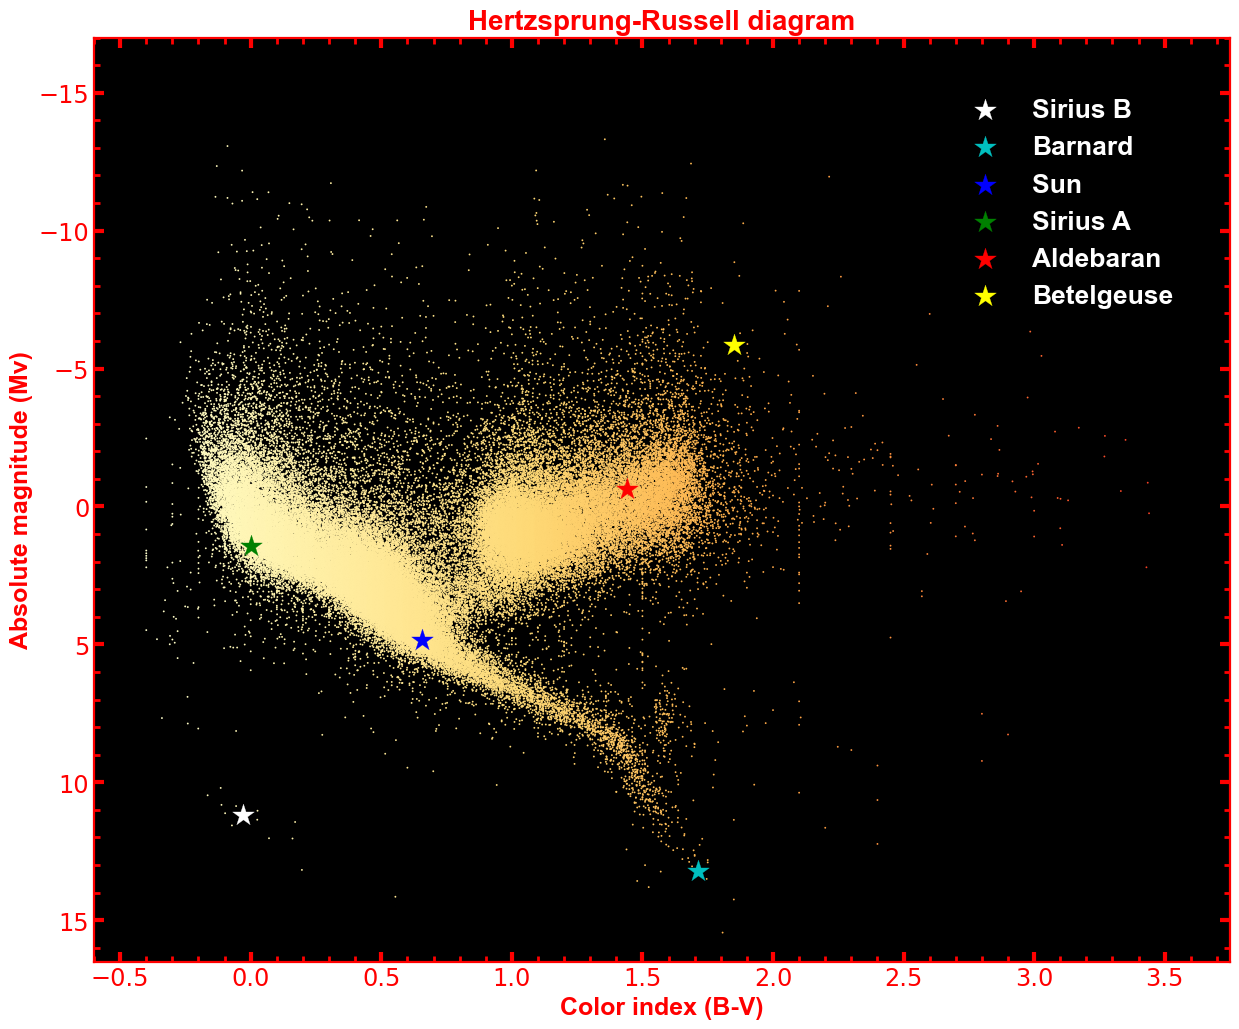

In [76]:
from matplotlib.ticker import AutoMinorLocator


fig, ax = plt.subplots(figsize=(12.5,10.4))
ax.scatter(df["B-V"], df["Absmag"], c=df["B-V"],  cmap = "YlOrRd", marker = '.', s = 7, linewidth = 0.01)
ax.scatter(x = -0.03, y = 11.18, c = "white", marker = '*', s = 270, linewidth = 0.2, label = "Sirius B")
ax.scatter(x = 1.713, y = 13.21, c = "c", marker = '*', s = 270, linewidth = 0.2, label = "Barnard")
ax.scatter(x = 0.656, y = 4.83, c = "blue", marker = '*', s = 270, linewidth = 0.2, label = "Sun")
ax.scatter(x = 0, y = 1.42, c = "green", marker = '*', s = 270, linewidth = 0.2, label = "Sirius A")
ax.scatter(x = 1.44, y = -0.641, c = "red", marker = '*', s = 270, linewidth = 0.2, label = "Aldebaran")
ax.scatter(x = 1.85, y = -5.85, c = "yellow", marker = '*', s = 270, linewidth = 0.2, label = "Betelgeuse")
plt.xlabel("Color index (B-V)", fontdict = Font1)
plt.ylabel("Absolute magnitude (Mv)", fontdict = Font1)
plt.title("Hertzsprung-Russell diagram", fontdict = Font2)
plt.xlim(-0.6, 3.75)
plt.ylim(16.5, -17) 
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis = "both", direction = "in", labelcolor='red', labelsize='xx-large', top = True, right = True)
ax.tick_params(which='major', direction = "in", color='red', length=7, width = 3)
ax.tick_params(which='minor', direction = "in", length=4, color='red', width = 2, top = True, right = True)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_color("red")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.6)
Color_BC = plt.gca()
Color_BC.set_facecolor("black")
Color_BC.patch.set_alpha(1)
plt.legend(frameon = False, prop = Font3, labelcolor = "white", bbox_to_anchor = (0.74,0.96), loc = 2)
plt.tight_layout()
plt.show()

### Convert SpType into Giants and Dwarfs

In [77]:
#Copy the SpType column to a new column called TargetClass
df['TargetClass'] = df['SpType']
df

,Vmag,Plx,e_Plx,B-V,SpType,Absmag,TargetClass
0,9.10,3.54,1.39,0.482,F5,1.845016,F5
1,9.27,21.90,3.10,0.999,K3V,5.972221,K3V
2,6.61,2.81,0.63,-0.019,B9,-1.146469,B9
3,8.06,7.75,0.97,0.370,F0V,2.506509,F0V
4,8.55,2.87,1.11,0.902,G8III,0.839409,G8III
...,...,...,...,...,...,...,...
93551,7.69,6.60,0.92,1.110,K2III,1.787720,K2III
93552,7.92,3.93,1.24,0.133,Am...,0.891963,Am...
93553,8.72,3.07,0.87,0.097,B3,1.155692,B3
93554,8.08,1.07,0.68,1.094,G5,-1.773081,G5


In [78]:
for i in range(len(df['TargetClass'])):
    if "V" in df.loc[i,'TargetClass']: 
        if "VII" in df.loc[i,'TargetClass']: 
            df.loc[i,'TargetClass'] = 0 # VII is Dwarf
        else:
            df.loc[i,'TargetClass'] = 1 # IV, V, VI are Giants
    elif "I" in df.loc[i,'TargetClass']: 
        df.loc[i,'TargetClass'] = 0 # I, II, III are Dwarfs
    else: 
        df.loc[i,'TargetClass'] = 9 # None
        
df

,Vmag,Plx,e_Plx,B-V,SpType,Absmag,TargetClass
0,9.10,3.54,1.39,0.482,F5,1.845016,9
1,9.27,21.90,3.10,0.999,K3V,5.972221,1
2,6.61,2.81,0.63,-0.019,B9,-1.146469,9
3,8.06,7.75,0.97,0.370,F0V,2.506509,1
4,8.55,2.87,1.11,0.902,G8III,0.839409,0
...,...,...,...,...,...,...,...
93551,7.69,6.60,0.92,1.110,K2III,1.787720,0
93552,7.92,3.93,1.24,0.133,Am...,0.891963,9
93553,8.72,3.07,0.87,0.097,B3,1.155692,9
93554,8.08,1.07,0.68,1.094,G5,-1.773081,9


### Drop Other Type of Stars

In [79]:
#Dropping rows that `TargetClass` = 9
df = df[df.TargetClass != 9]

#Reindex the dataframe
df = df.reset_index(drop=True)

df

,Vmag,Plx,e_Plx,B-V,SpType,Absmag,TargetClass
0,9.27,21.900000,3.10,0.999,K3V,5.972221,1
1,8.06,7.750000,0.97,0.370,F0V,2.506509,1
2,8.55,2.870000,1.11,0.902,G8III,0.839409,0
3,12.31,18.799999,4.99,1.336,M0V:,8.680790,1
4,8.59,10.760000,1.10,0.489,F6V,3.749062,1
...,...,...,...,...,...,...,...
46233,9.26,2.680000,1.36,0.521,F5V,1.400674,1
46234,8.79,0.890000,1.28,1.194,K1III,-1.463050,0
46235,8.00,0.410000,0.92,0.854,F6Iab,-3.936081,0
46236,7.69,6.600000,0.92,1.110,K2III,1.787720,0


### Reducing and Balancing The Datasets

In [80]:
df_giants = df[df.TargetClass == 1]
df_dwarfs = df[df.TargetClass == 0]

# Numbers of rows of Giants and Dwarfs
num_of_giant = df_giants.shape[0]
num_of_dwarf = df_dwarfs.shape[0]
print("Giants(1):",num_of_giant)
print("Dwarfs(0):",num_of_dwarf)

Giants(1): 27311
Dwarfs(0): 18927


In [81]:
# Make Dwarfts = 500 rows of data
df_dwarfs = resample(df_dwarfs, replace=True, n_samples=500, random_state=42)

# Numbers of rows of Dwarfs
num_of_dwarf = df_dwarfs.shape[0]
print("Dwarfs(0):",num_of_dwarf)

Dwarfs(0): 500


In [82]:
# Downsampling the majority class (Giants)

df_giants_downsampled = resample(df_giants, 
                                 replace=False,    # sample without replacement
                                 n_samples=num_of_dwarf,     # to match minority class
                                 random_state=1) # reproducible results
 
# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_giants_downsampled, df_dwarfs])
df_downsampled['TargetClass'].value_counts()

TargetClass
1    500
0    500
Name: count, dtype: int64

In [83]:
df_balanced = df_downsampled.reset_index(drop=True)
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vmag         1000 non-null   float32
 1   Plx          1000 non-null   float32
 2   e_Plx        1000 non-null   float32
 3   B-V          1000 non-null   float32
 4   SpType       1000 non-null   object 
 5   Absmag       1000 non-null   float32
 6   TargetClass  1000 non-null   object 
dtypes: float32(5), object(2)
memory usage: 35.3+ KB


In [84]:
df = df_balanced
df

,Vmag,Plx,e_Plx,B-V,SpType,Absmag,TargetClass
0,6.00,7.43,0.85,1.152,K1IV,0.354944,1
1,8.04,10.74,1.07,0.530,F8IV-V,3.195021,1
2,9.09,3.33,1.14,0.534,F8V,1.702221,1
3,9.37,13.30,1.38,0.673,G2V,4.989258,1
4,7.23,12.75,0.59,0.413,F3V,2.757551,1
...,...,...,...,...,...,...,...
995,7.86,3.21,0.66,1.015,G6III,0.392525,0
996,7.83,1.70,0.70,1.533,K3III,-1.017756,0
997,9.26,4.43,0.80,1.278,K3III,2.492019,0
998,9.20,4.06,1.12,0.228,A5III,2.242630,0


## Exploratory Data Analysis

In [85]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vmag         1000 non-null   float32
 1   Plx          1000 non-null   float32
 2   e_Plx        1000 non-null   float32
 3   B-V          1000 non-null   float32
 4   SpType       1000 non-null   object 
 5   Absmag       1000 non-null   float32
 6   TargetClass  1000 non-null   object 
dtypes: float32(5), object(2)
memory usage: 35.3+ KB


(1000, 7)

##### This preprocessed dataset has 1000 rows of data and 6 features. The dataset includes features such as Vmag (visual magnitude), Plx (distance to Earth), e_Plx (standard error of Plx), B-V (color index), SpType (spectral type), and Absmag (absolute magnitude). The target class is formed based on the classification of stars as either dwarfs (0) or giants (1) depending on their characteristics.

In [86]:
# Drop SpType column as it is not needed anymore (use TargetClass instead)
df = df.drop(['SpType'], axis=1)

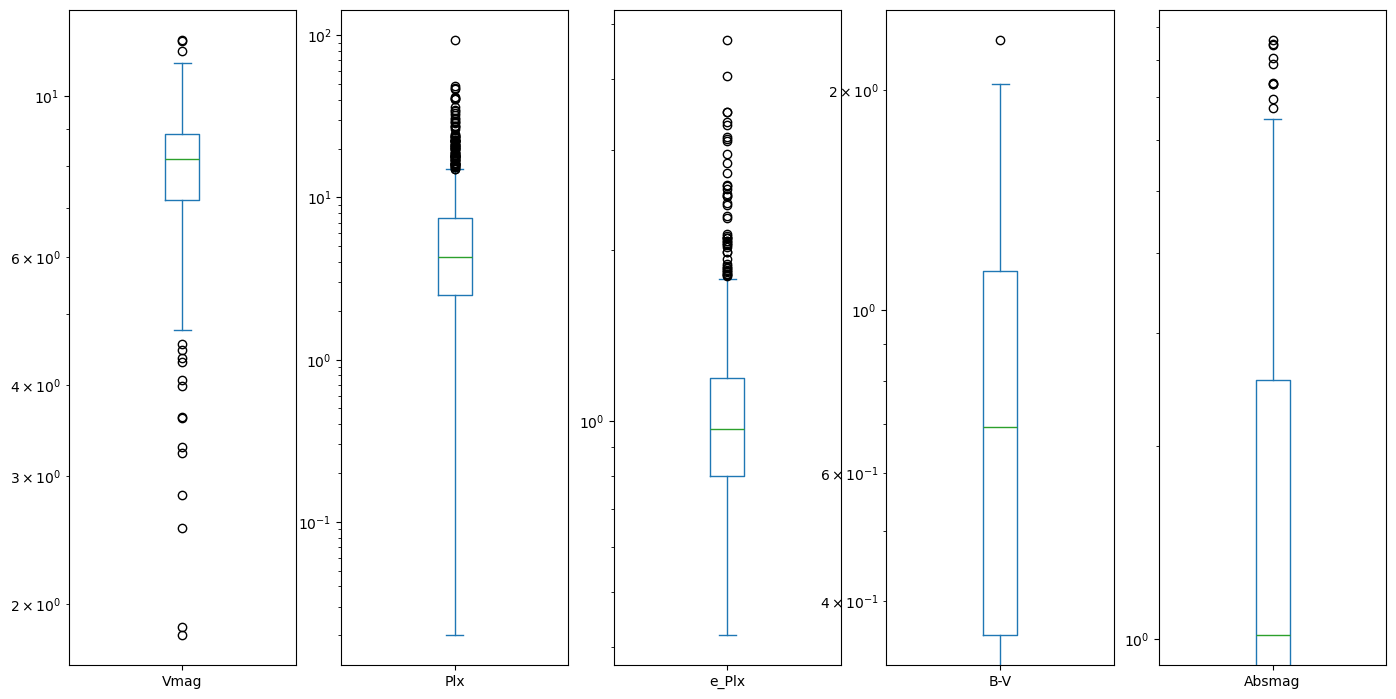

In [87]:
# Boxplot
ax = df.plot(kind='box', subplots=True, layout=(8, 5), figsize=(17,80))

# Apply log scale
for subplot in ax:
    subplot.set_yscale('log')

plt.show()

#### Boxplot diatas digunakan untuk membuat visualisasi data dari kelima feature yang digunakan. 

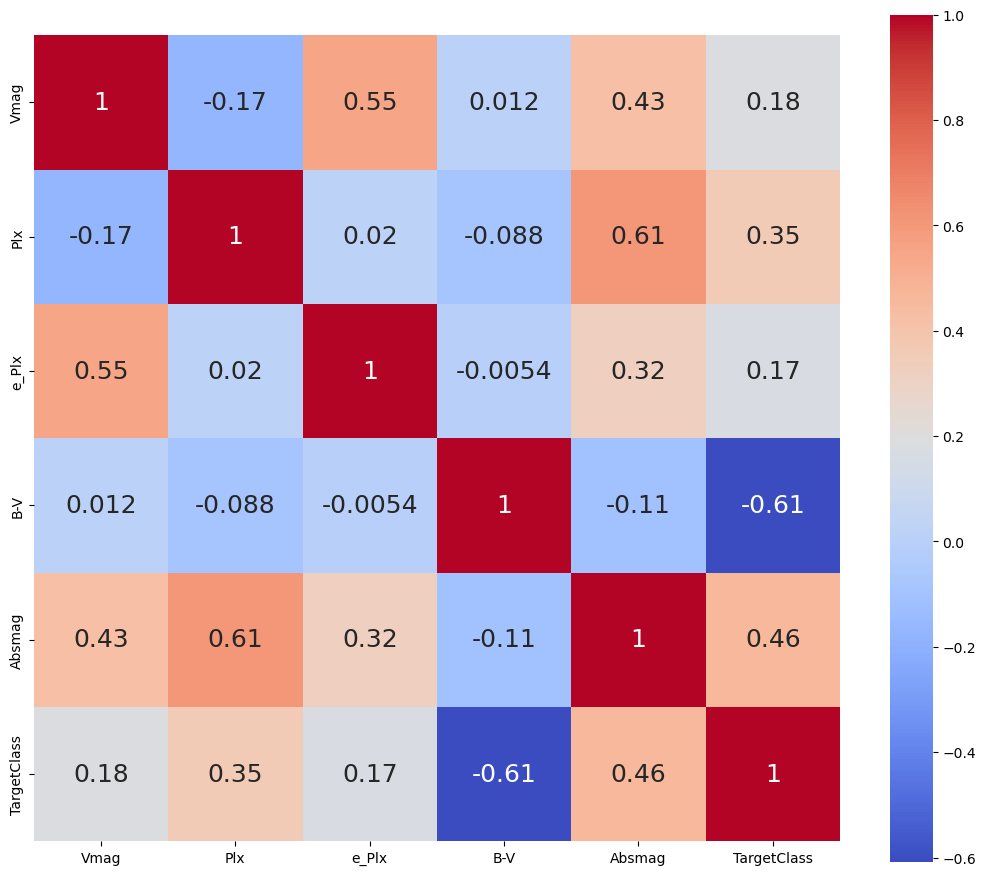

In [88]:
# Heatmap
corr = df.corr()
plt.figure(figsize=(13,11)) 
sns.heatmap(corr, annot = True, cbar=True, square= True, annot_kws={'size':18}, cmap='coolwarm')
plt.show()

#### Penjelasan Heatmap
- Feature yang paling berpengaruh terhadap TargetClass adalah Absmag dengan perolehan data dari heatmap adalah 0.46.
- Feature yang paling tidak berpengaruh terhadap TargetClass adalah B-V dengan perolehan data dari heatmap adalah -0.61.

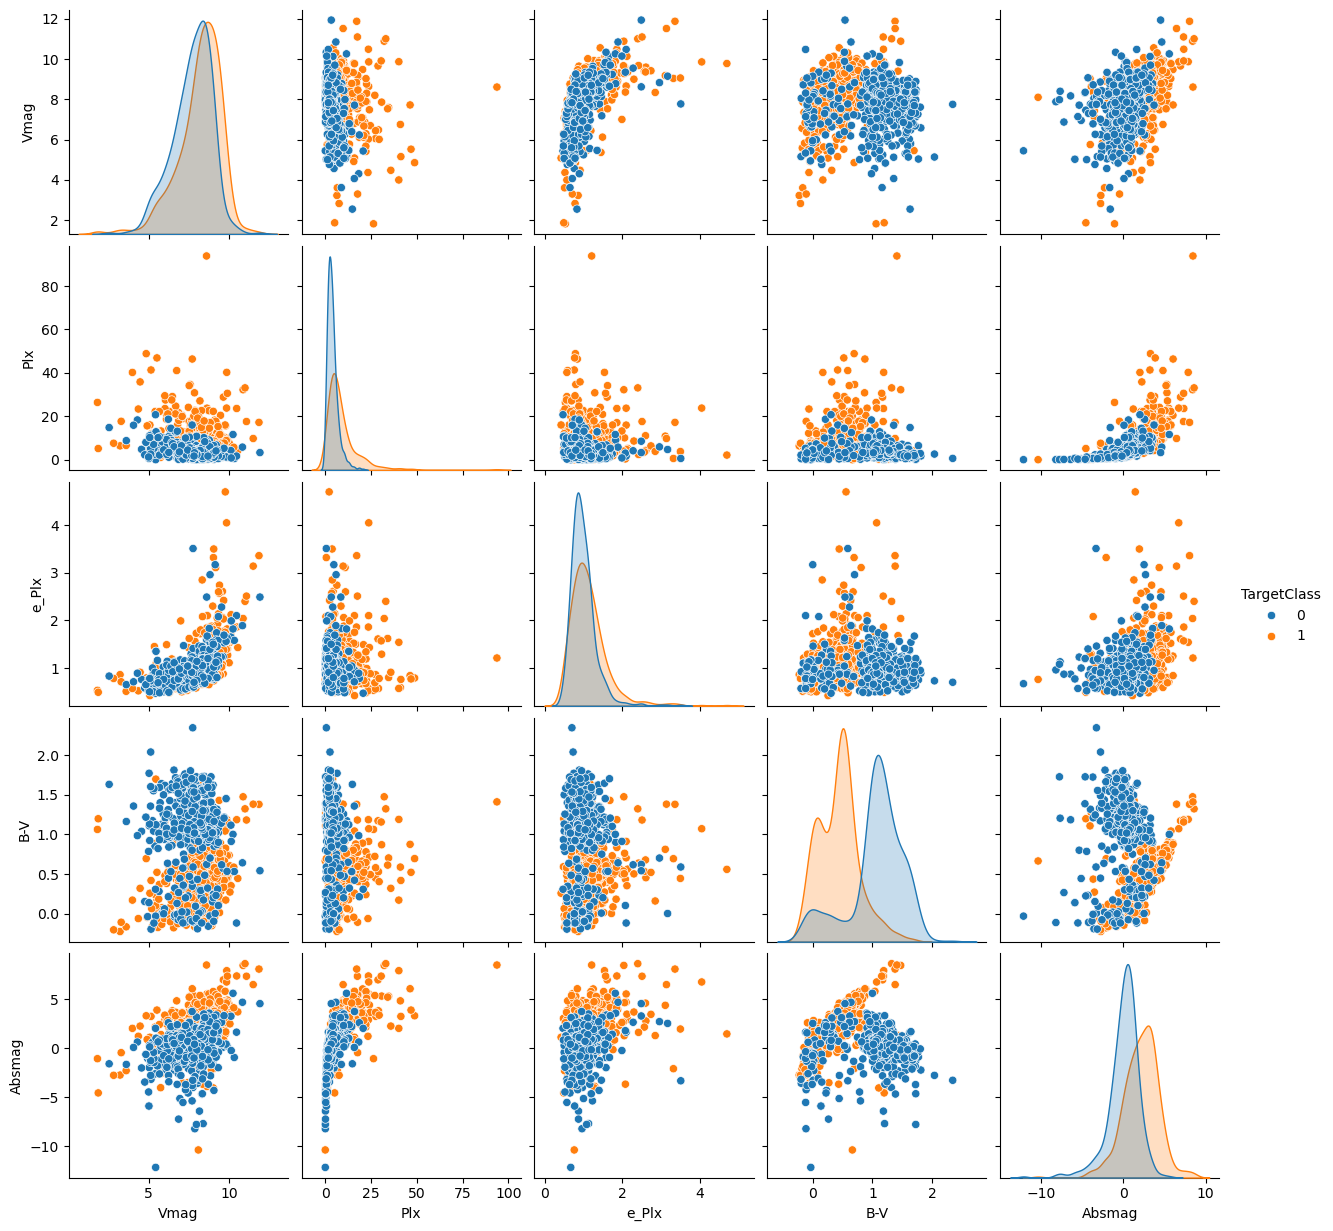

In [89]:
# Scatterplot matrix
sns.pairplot(df, hue='TargetClass')
plt.show()

#### Scatterplot diatas digunakan untuk menggambarkan relasi pasangan feature yang ada terhadap TargetClass. Grafik ini dapat memberikan gambaran mengenai korelasi, pencilan, kelompok data (clusters), dll.

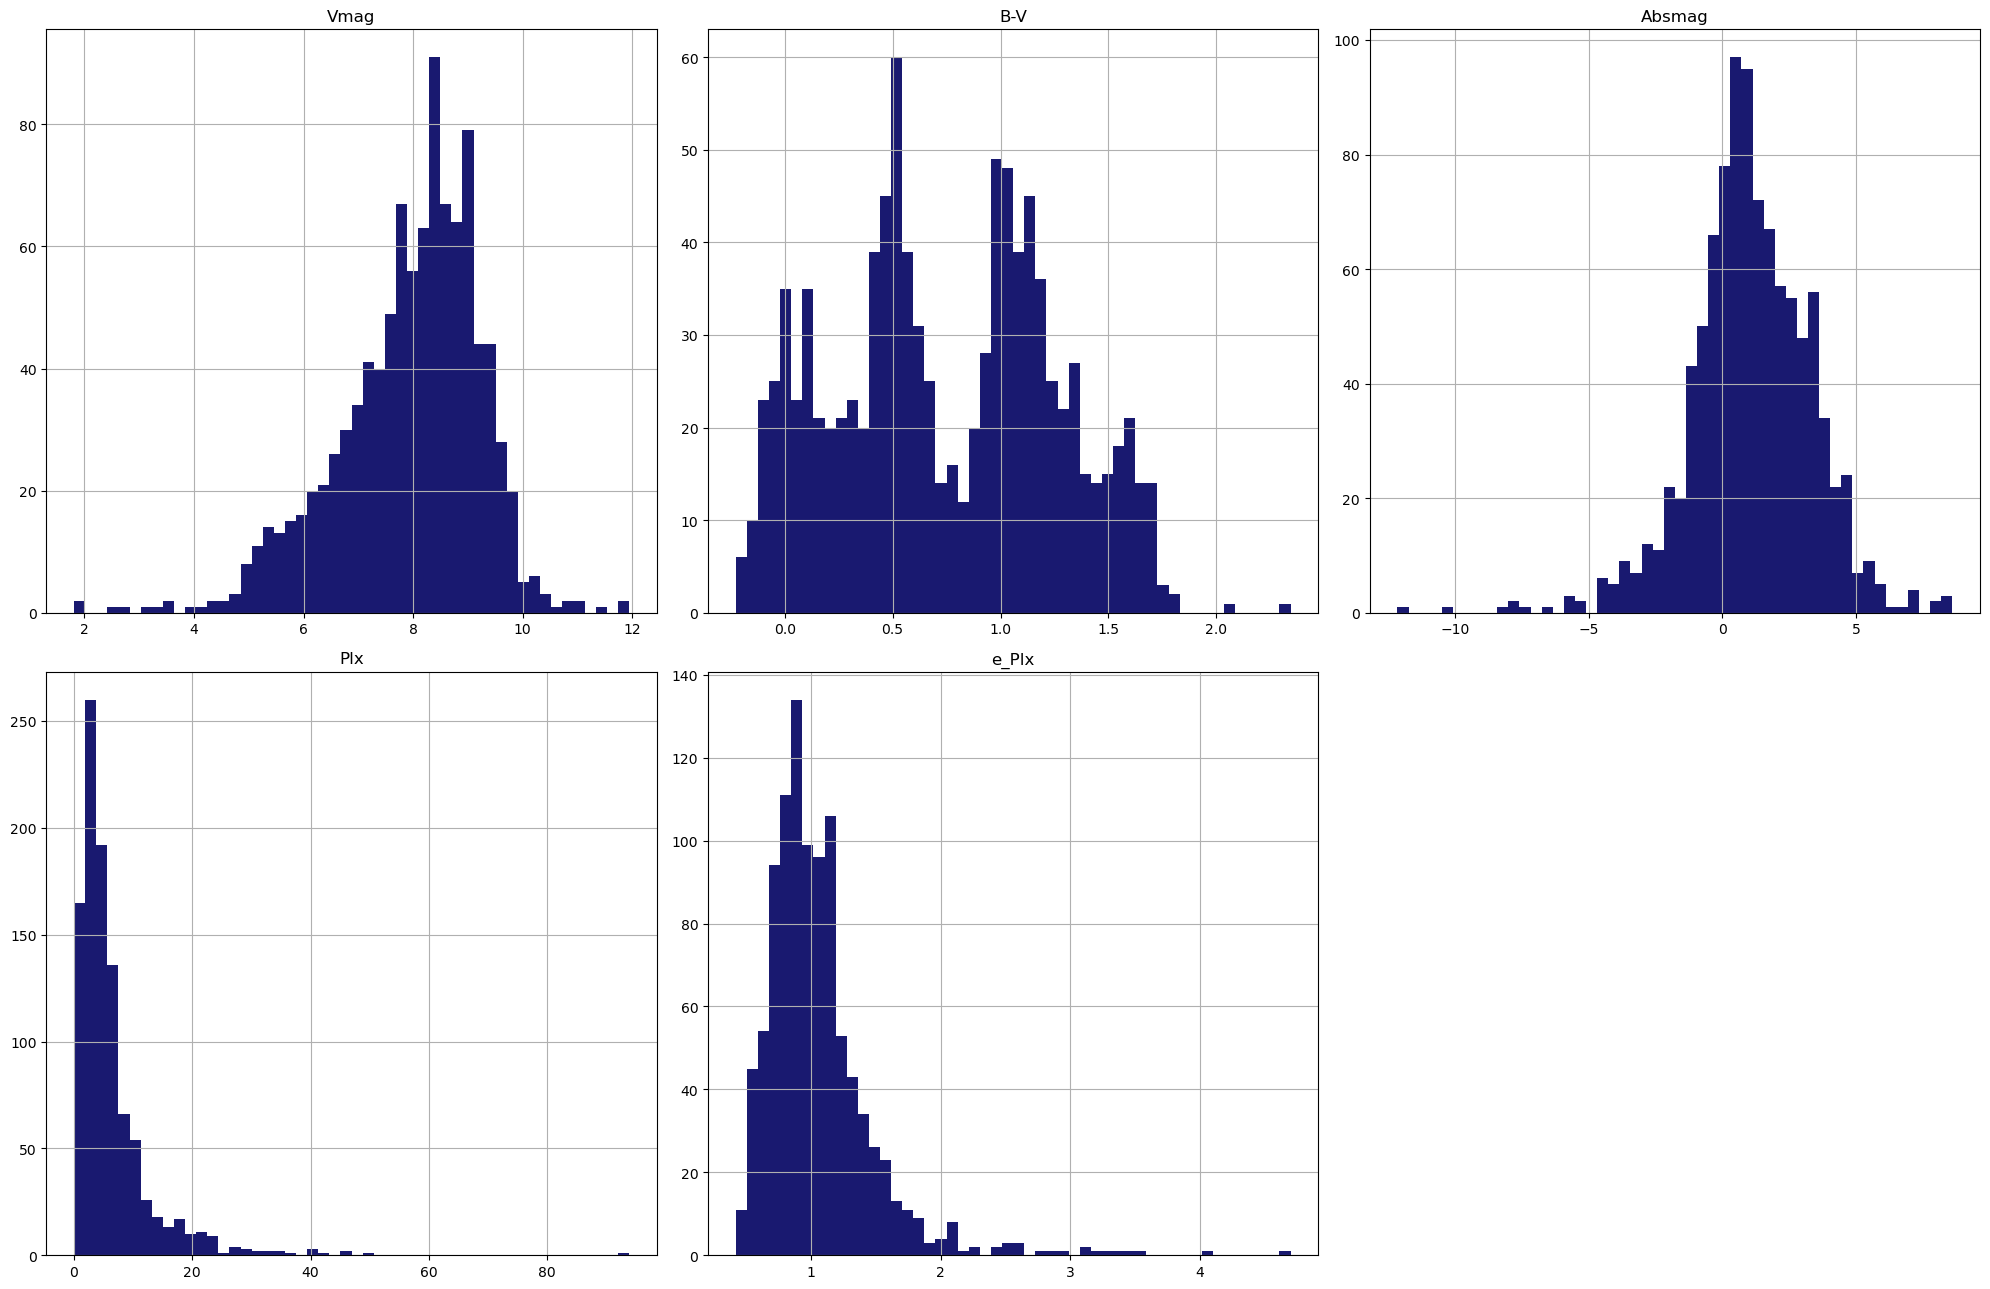

In [90]:
# Histogram
df[["Vmag", "B-V", "Absmag", "Plx", "e_Plx"]].hist(figsize=(20,13), color="midnightblue", bins=50, layout= (2,3))
plt.tight_layout()
plt.show()

#### Grafik histogram diatas memberikan gambaran mengenai rentang data dan modus yang ada di setiap feature.

## Splitting Data (Train and Test)

In [91]:
X = df.drop('TargetClass', axis = 1)
y = df[['TargetClass']]

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state=42, shuffle=True, stratify = y)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

## Model Tuning

In [93]:
results = {}

### Logistic Regression

In [94]:
# Logistic Regression
def logistic_regression(X_train, X_test, y_train, y_test):
    lr = LogisticRegression(random_state=42)
    
    # Define the hyperparameters grid
    param_grid = {
        'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', lr)  # Replace with your model
    ])
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10)   
    
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
    
    # Fit the GridSearchCV object to the data
    grid_search.fit(X_train, y_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_

    # Predict the test set results
    y_pred = grid_search.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("Logistic Regression")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')
    
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}

Logistic Regression
Best Parameters:  {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Accuracy:  0.904
Precision: 0.9041034504833237
Recall: 0.904
F1 Score: 0.9039938556067588
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       125
           1       0.90      0.91      0.90       125

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

StratifiedKFold
Cross-validation scores: [0.88       0.92       0.89333333 0.89333333 0.8        0.89333333
 0.84       0.86666667 0.90666667 0.92      ]
Average cross-validation score: 0.8813333333333333
KFold
Cross-validation scores: [0.86666667 0.90666667 0.89333333 0.89333333 0.8        0.89333333
 0.84       0.86666667 0.92       0.92      ]
Average cross-validation score: 0.8800000000000001


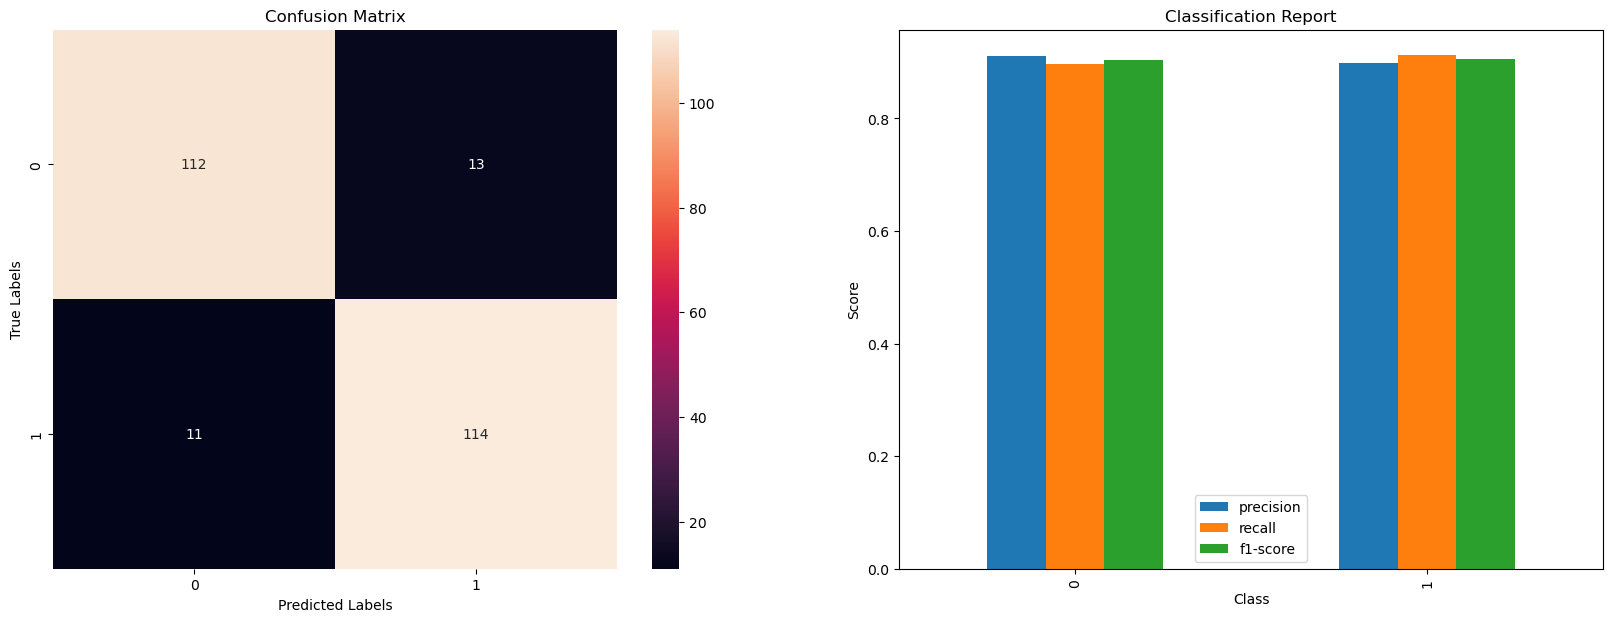

In [95]:
results['Logistic Regression'] = logistic_regression(X_train, X_test, y_train, y_test)

### Naive Bayes

In [96]:
# Naive Bayes
def naive_bayes(X_train, X_test, y_train, y_test):
    classifier = GaussianNB()
    
    # Define the hyperparameters grid
    param_grid = {
        'classifier__var_smoothing': np.logspace(0,-9, num=100)
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', classifier)  # Naive Bayes model
    ])
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10) 
    
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
    
    # Fit the GridSearchCV object to the data
    grid_search.fit(X_train, y_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_
    
    # Predict the test set results
    y_pred = grid_search.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("Naive Bayes")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')
    
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}

Naive Bayes
Best Parameters:  {'classifier__var_smoothing': 0.8111308307896871}
Accuracy:  0.876
Precision: 0.8869204425711276
Recall: 0.876
F1 Score: 0.8751188385246298
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.89       125
           1       0.95      0.79      0.86       125

    accuracy                           0.88       250
   macro avg       0.89      0.88      0.88       250
weighted avg       0.89      0.88      0.88       250

StratifiedKFold
Cross-validation scores: [0.81333333 0.8        0.81333333 0.81333333 0.81333333 0.81333333
 0.84       0.8        0.8        0.81333333]
Average cross-validation score: 0.8119999999999999
KFold
Cross-validation scores: [0.81333333 0.81333333 0.81333333 0.81333333 0.81333333 0.82666667
 0.85333333 0.8        0.78666667 0.81333333]
Average cross-validation score: 0.8146666666666667


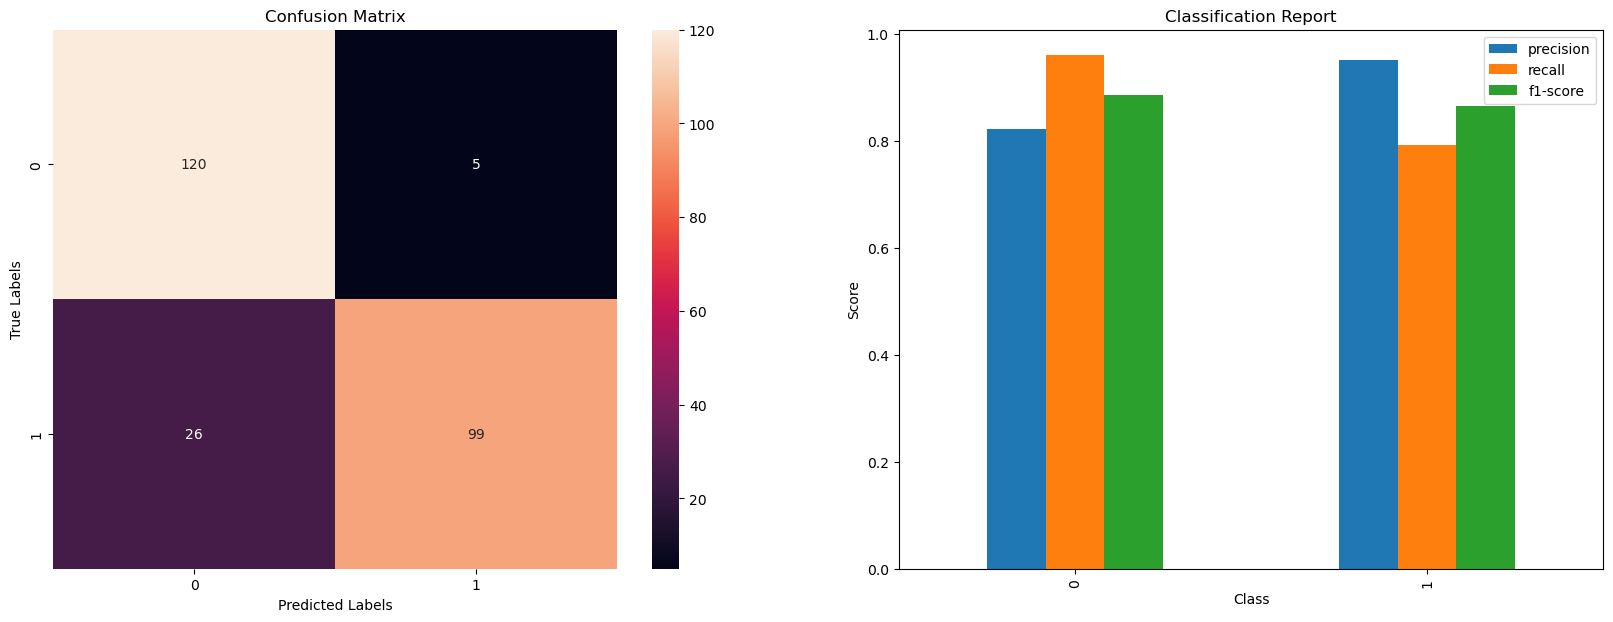

In [97]:
results['Naive Bayes'] = naive_bayes(X_train, X_test, y_train, y_test)

### KNN

In [98]:
# KNN
def KNN(X_train, X_test, y_train, y_test):
    knn = KNeighborsClassifier()
    
    # Define the hyperparameters grid
    param_grid = {
        'classifier__n_neighbors': list(range(1, 31)),
        'classifier__weights': ['uniform', 'distance'],
        'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', knn)  # KNN model
    ])
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10) 
        
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
    
    # Fit the GridSearchCV object to the data
    grid_search.fit(X_train, y_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_
    
    # Predict the test set results
    y_pred = grid_search.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("KNN")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')
    
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}

KNN
Best Parameters:  {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 10, 'classifier__weights': 'uniform'}
Accuracy:  0.884
Precision: 0.8840245775729647
Recall: 0.884
F1 Score: 0.8839981439703035
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       125
           1       0.89      0.88      0.88       125

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

StratifiedKFold
Cross-validation scores: [0.88       0.89333333 0.89333333 0.89333333 0.82666667 0.81333333
 0.85333333 0.86666667 0.90666667 0.90666667]
Average cross-validation score: 0.8733333333333333
KFold
Cross-validation scores: [0.88       0.89333333 0.88       0.89333333 0.81333333 0.81333333
 0.84       0.88       0.90666667 0.90666667]
Average cross-validation score: 0.8706666666666667


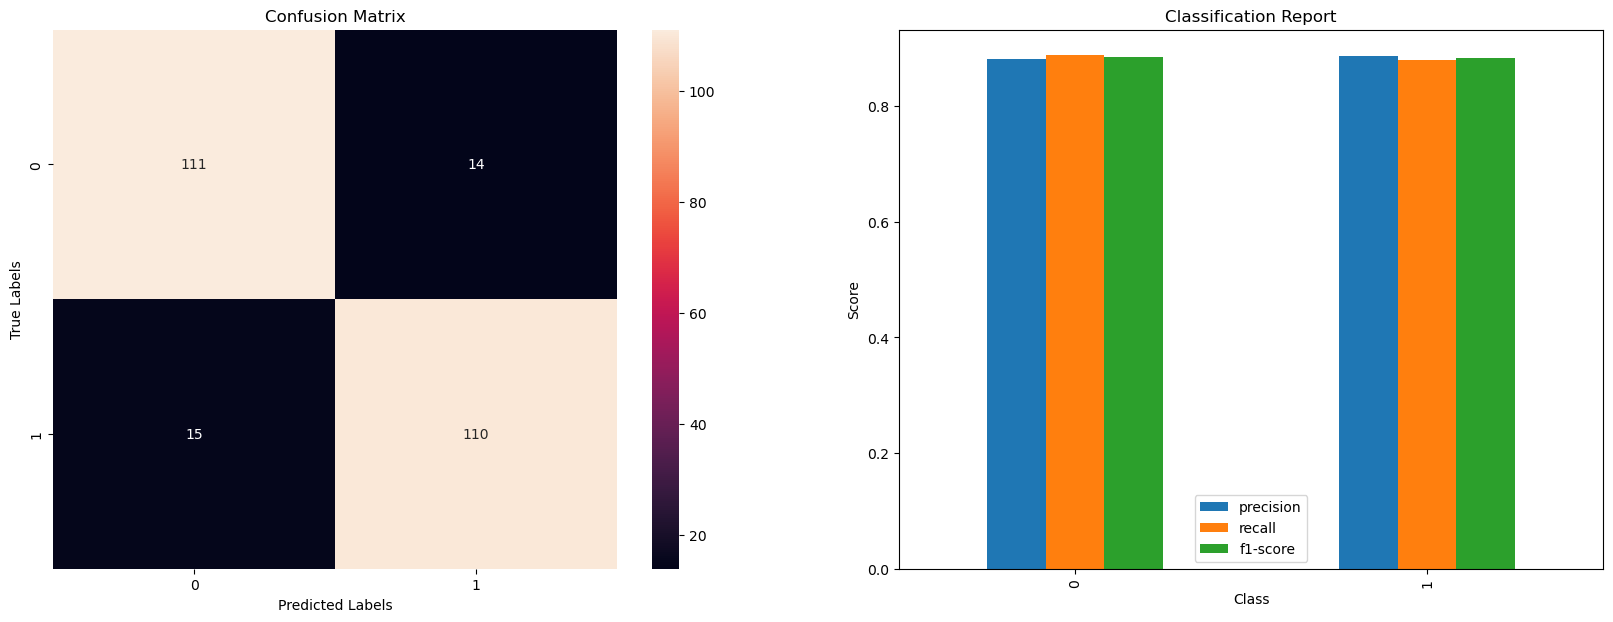

In [99]:
results['KNN'] = KNN(X_train, X_test, y_train, y_test)

### SVC

In [100]:
def svc_model(X_train, X_test, y_train, y_test):
    svc = SVC(random_state=42)

    # Define the hyperparameters grid
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': [1, 0.1, 0.01],
        'classifier__kernel': ['linear', 'rbf']
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', svc)  # SVC model
    ])
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10) 
        
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
    
    # Fit the GridSearchCV object to the data
    grid_search.fit(X_train, y_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_
    
    # Predict the test set results
    y_pred = grid_search.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("SVC")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')

    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}

SVC
Best Parameters:  {'classifier__C': 0.1, 'classifier__gamma': 1, 'classifier__kernel': 'linear'}
Accuracy:  0.908
Precision: 0.908235143442623
Recall: 0.908
F1 Score: 0.9079867500920134
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       125
           1       0.90      0.92      0.91       125

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

StratifiedKFold
Cross-validation scores: [0.86666667 0.90666667 0.89333333 0.89333333 0.81333333 0.85333333
 0.85333333 0.88       0.90666667 0.92      ]
Average cross-validation score: 0.8786666666666667
KFold
Cross-validation scores: [0.86666667 0.90666667 0.89333333 0.89333333 0.81333333 0.86666667
 0.85333333 0.88       0.90666667 0.92      ]
Average cross-validation score: 0.8800000000000001


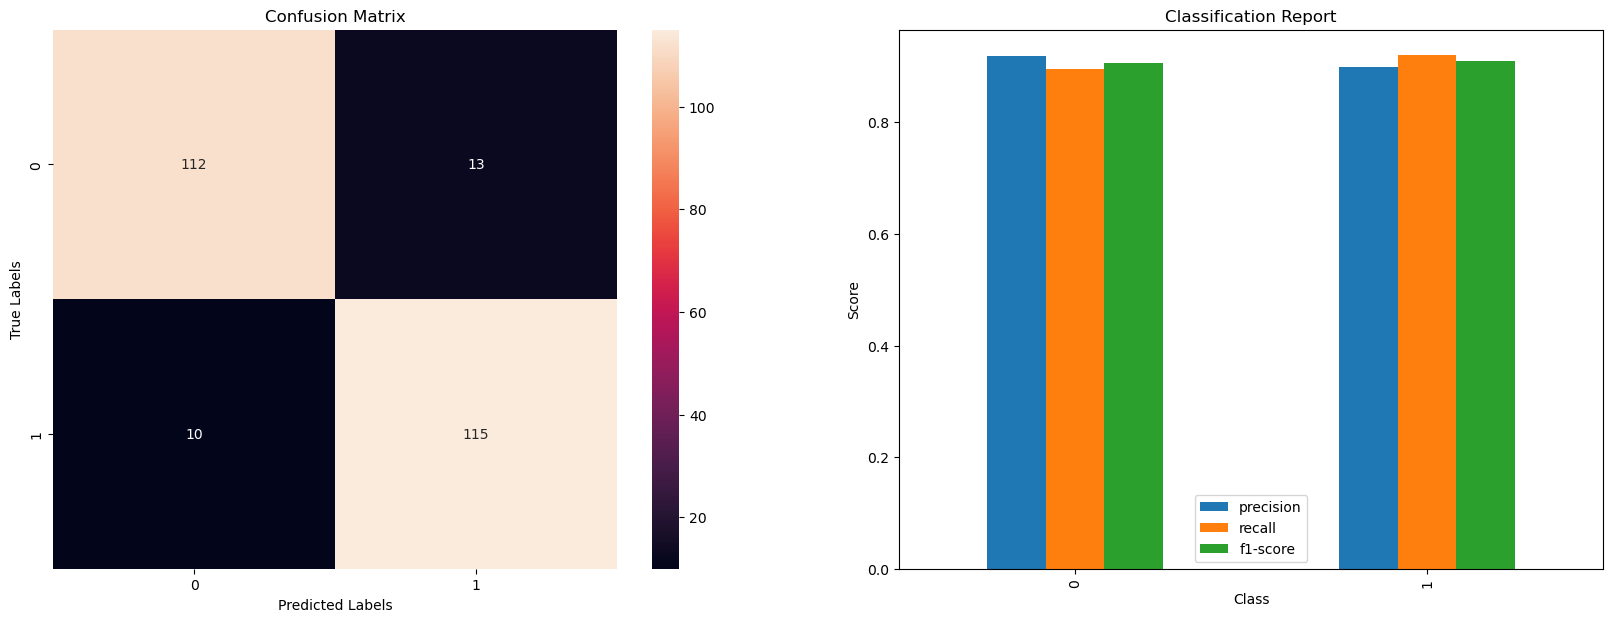

In [101]:
results['SVC'] = svc_model(X_train, X_test, y_train, y_test)

### MLP

In [102]:
# MLP (1 hidden layer, 2 hidden layers)
def MLP(X_train, X_test, y_train, y_test):
    mlp = MLPClassifier(max_iter=1000)
    
    # Define the hyperparameters grid
    param_grid = {
        'classifier__hidden_layer_sizes': [(50,), (100,)],
        'classifier__activation': ['relu'],
        'classifier__solver': ['adam'],
        'classifier__alpha': [0.0001],
        'classifier__learning_rate': ['adaptive'],
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', mlp)  # MLP model
    ])
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10) 
        
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
    
    # Fit the GridSearchCV object to the data
    grid_search.fit(X_train, y_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_
    
    # Predict the test set results
    y_pred = grid_search.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("MLP")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')

    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}


MLP
Best Parameters:  {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate': 'adaptive', 'classifier__solver': 'adam'}
Accuracy:  0.912
Precision: 0.912
Recall: 0.912
F1 Score: 0.912
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       125
           1       0.91      0.91      0.91       125

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

StratifiedKFold
Cross-validation scores: [0.88       0.90666667 0.88       0.89333333 0.82666667 0.88
 0.82666667 0.85333333 0.89333333 0.90666667]
Average cross-validation score: 0.8746666666666668
KFold
Cross-validation scores: [0.88       0.90666667 0.88       0.89333333 0.82666667 0.86666667
 0.82666667 0.86666667 0.90666667 0.90666667]
Average cross-validation score: 0.876


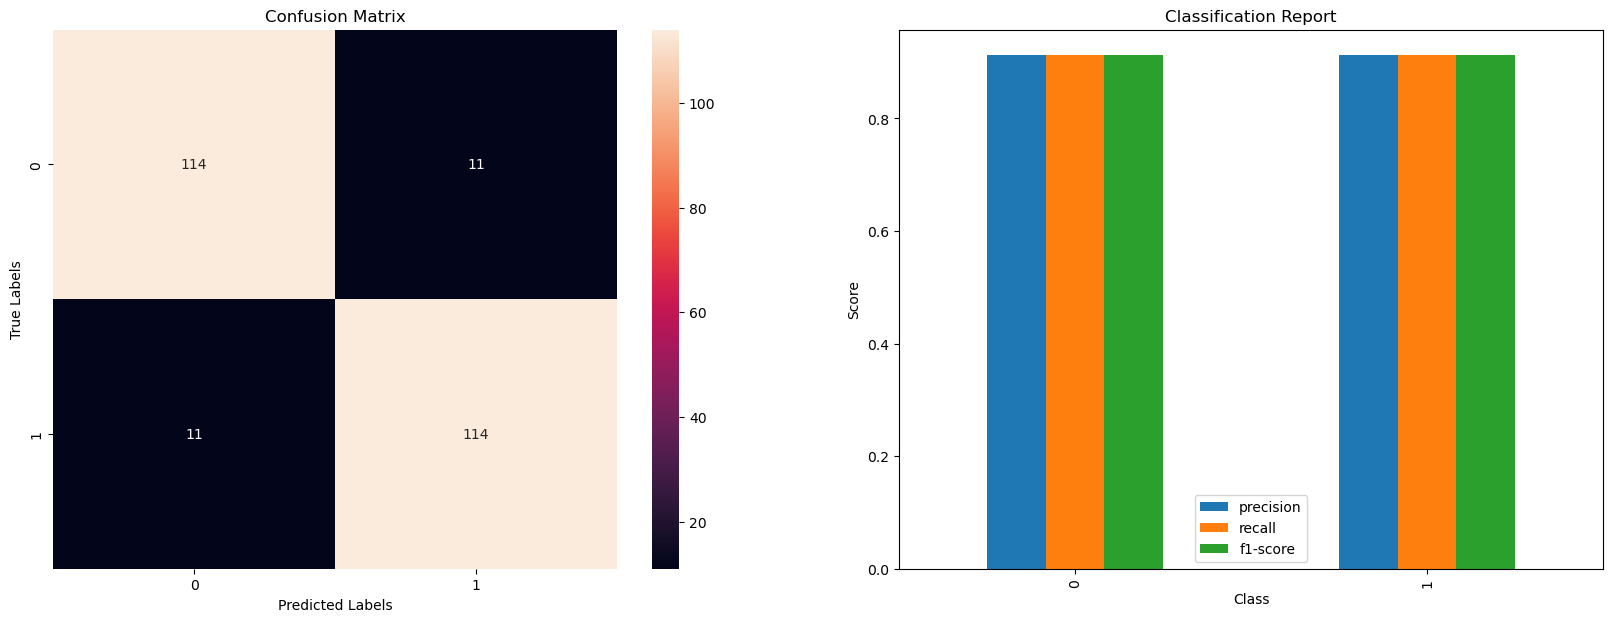

In [103]:
results['MLP'] = MLP(X_train, X_test, y_train, y_test)

### Desicion Tree

In [104]:
# Decision Tree
def decision_tree(X_train, X_test, y_train, y_test):
    dt = DecisionTreeClassifier(random_state=42)

    # Define the parameter grid
    param_grid = {
        'classifier__criterion': ['gini', 'entropy'],
        'classifier__max_depth': [None, 2, 4, 6, 8, 10],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', dt)  # Decision Tree model
    ])

    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10) 
    
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

    # Fit GridSearchCV
    grid_search.fit(X_train, y_train)

    # Get the best parameters
    best_params = grid_search.best_params_

    # Predict using the best model
    y_pred = grid_search.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("Decision Tree")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')

    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}

Decision Tree
Best Parameters:  {'classifier__criterion': 'entropy', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}
Accuracy:  0.896
Precision: 0.8961014019589015
Recall: 0.896
F1 Score: 0.8959933435739886
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       125
           1       0.89      0.90      0.90       125

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

StratifiedKFold
Cross-validation scores: [0.84       0.84       0.90666667 0.88       0.81333333 0.84
 0.82666667 0.86666667 0.86666667 0.94666667]
Average cross-validation score: 0.8626666666666667
KFold
Cross-validation scores: [0.85333333 0.84       0.89333333 0.85333333 0.8        0.86666667
 0.81333333 0.88       0.89333333 0.94666667]
Average cross-validation score: 0.86400000000000

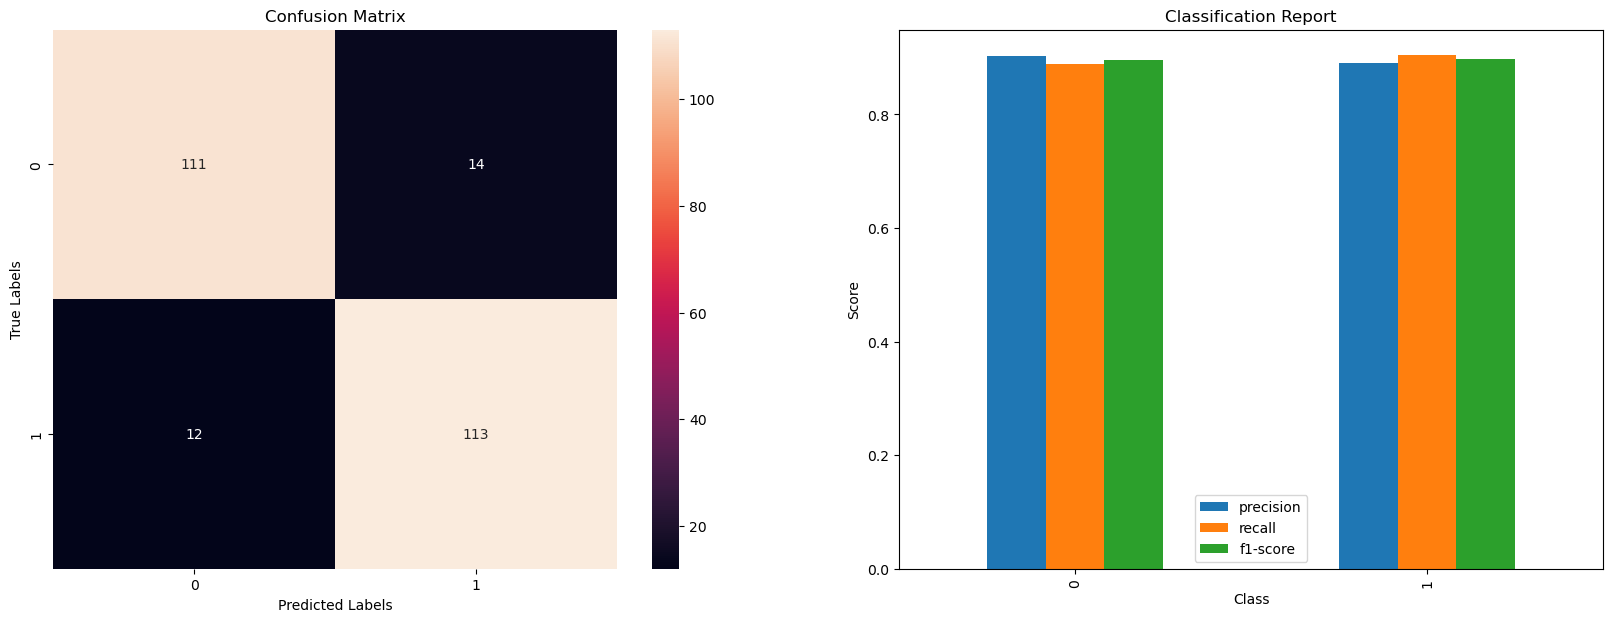

In [105]:
results['Desicion Tree'] = decision_tree(X_train, X_test, y_train, y_test)

### Random Forest

In [106]:
# Random Forest
def random_forest(X_train, X_test, y_train, y_test):
    rf = RandomForestClassifier(random_state=42)
    
    # Define the hyperparameters grid
    param_grid = {
        'classifier__n_estimators': [100, 500],
        'classifier__max_features': ['auto', 'sqrt'],
        'classifier__max_depth' : [4,8],
        'classifier__criterion' :['gini']
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', rf)  # Random Forest model
    ])
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10) 
        
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
    
    # Fit the GridSearchCV object to the data
    grid_search.fit(X_train, y_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_
    
    # Predict the test set results
    y_pred = grid_search.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("Random Forest")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')

    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}

Random Forest
Best Parameters:  {'classifier__criterion': 'gini', 'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 500}
Accuracy:  0.924
Precision: 0.9240271377368151
Recall: 0.924
F1 Score: 0.9239987839805438
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       125
           1       0.92      0.93      0.92       125

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

StratifiedKFold
Cross-validation scores: [0.88       0.92       0.89333333 0.92       0.81333333 0.88
 0.81333333 0.86666667 0.89333333 0.93333333]
Average cross-validation score: 0.8813333333333333
KFold
Cross-validation scores: [0.86666667 0.92       0.88       0.92       0.81333333 0.86666667
 0.8        0.86666667 0.89333333 0.90666667]
Average cross-validation score: 0.8733333333333334


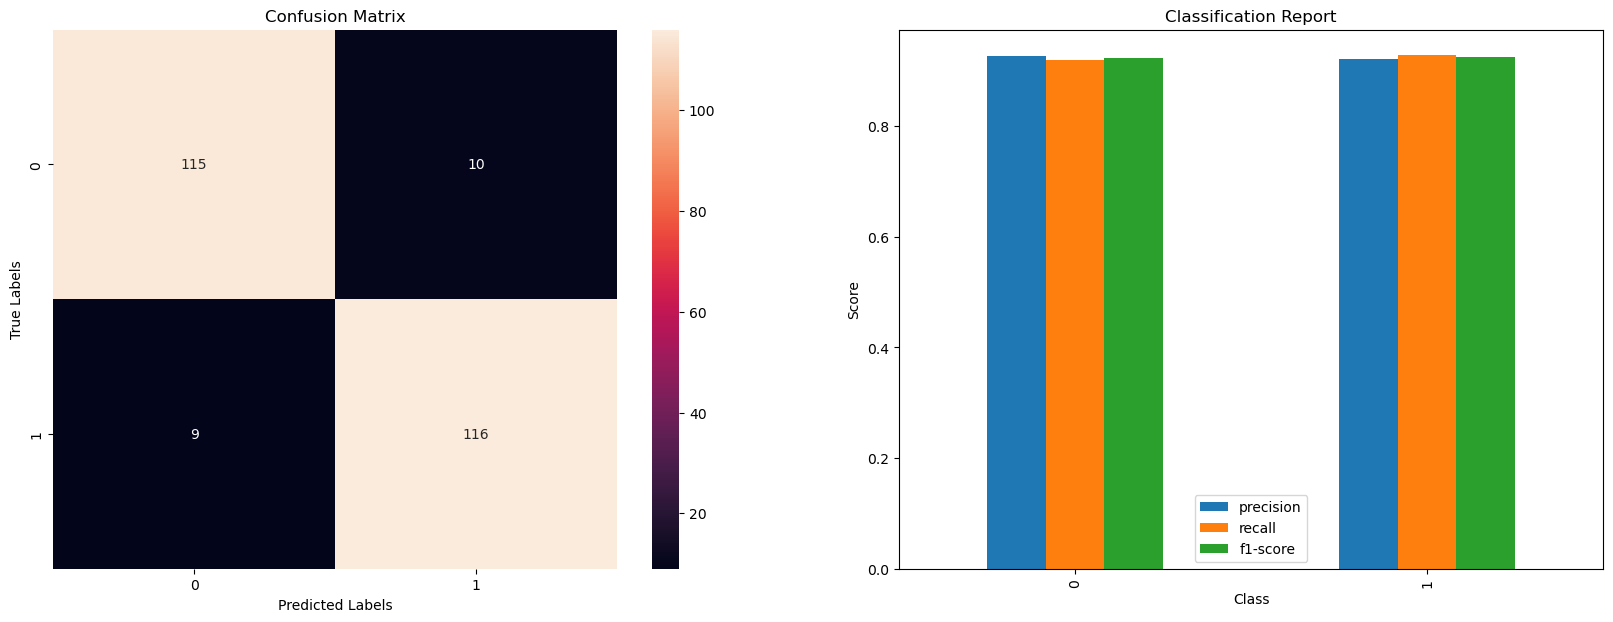

In [107]:
results['Random Forest'] = random_forest(X_train, X_test, y_train, y_test)

### Gradient Boosting

In [108]:
# Gradient Boosting
def gradient_boosting(X_train, X_test, y_train, y_test):
    gb = GradientBoostingClassifier(random_state=42)

    # Define the parameter grid
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 4],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    }

    # Define the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Scaling step
        ('classifier', gb)  # Gradient Boosting model
    ])

    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=10)
    kf = KFold(n_splits = 10) 
    
    # Create a GridSearchCV object
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

    # Fit GridSearchCV
    grid_search.fit(X_train, y_train)

    # Get the best parameters
    best_params = grid_search.best_params_

    # Predict using the best model
    y_pred = grid_search.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("Decision Tree")
    print("Best Parameters: ", best_params)
    print("Accuracy: ", acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=skf)
    print('StratifiedKFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Perform stratified 5-fold cross validation
    scores = cross_val_score(grid_search, X_train, y_train, cv=kf)
    print('KFold')
    print('Cross-validation scores:', scores)
    print('Average cross-validation score:', scores.mean())

    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # Plot the confusion matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Labels')
    ax[0].set_ylabel('True Labels')

    # Display the classification report on the second subplot
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Select only the rows for classes 0 and 1 and the columns for precision, recall, and f1-score
    selected_report_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

    selected_report_df.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Classification Report')
    ax[1].set_ylabel('Score')
    ax[1].set_xlabel('Class')

    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'average_cv_score': scores.mean(), 'best_params': best_params}

Decision Tree
Best Parameters:  {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Accuracy:  0.904
Precision: 0.9044141200589404
Recall: 0.904
F1 Score: 0.903975417706933
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       125
           1       0.89      0.92      0.91       125

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

StratifiedKFold
Cross-validation scores: [0.86666667 0.90666667 0.88       0.90666667 0.81333333 0.86666667
 0.82666667 0.84       0.89333333 0.92      ]
Average cross-validation score: 0.8720000000000001
KFold
Cross-validation scores: [0.85333333 0.92       0.88       0.90666667 0.8        0.85333333
 0.81333333 0.88       0.89333333 0.92      ]
Average cros

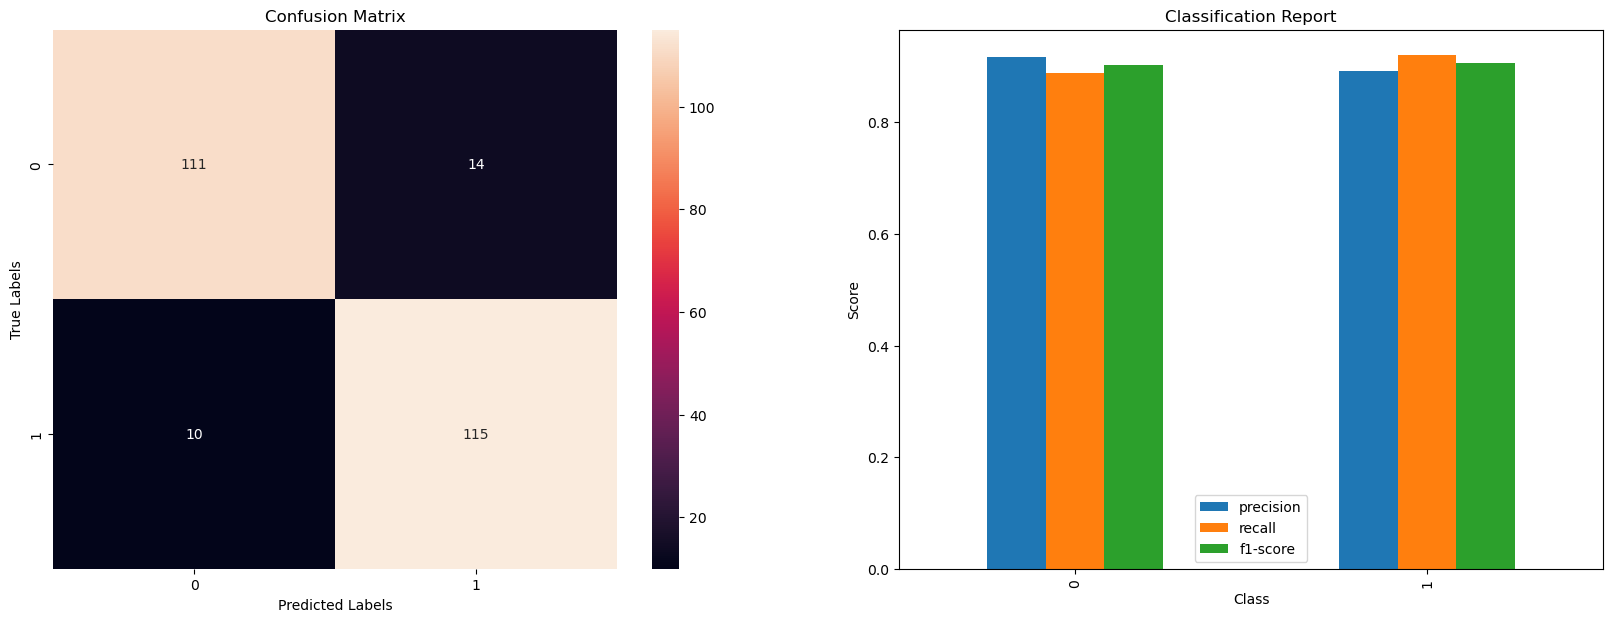

In [109]:
results['Gradient Boosting'] = gradient_boosting(X_train, X_test, y_train, y_test)

## Evaluasi Model

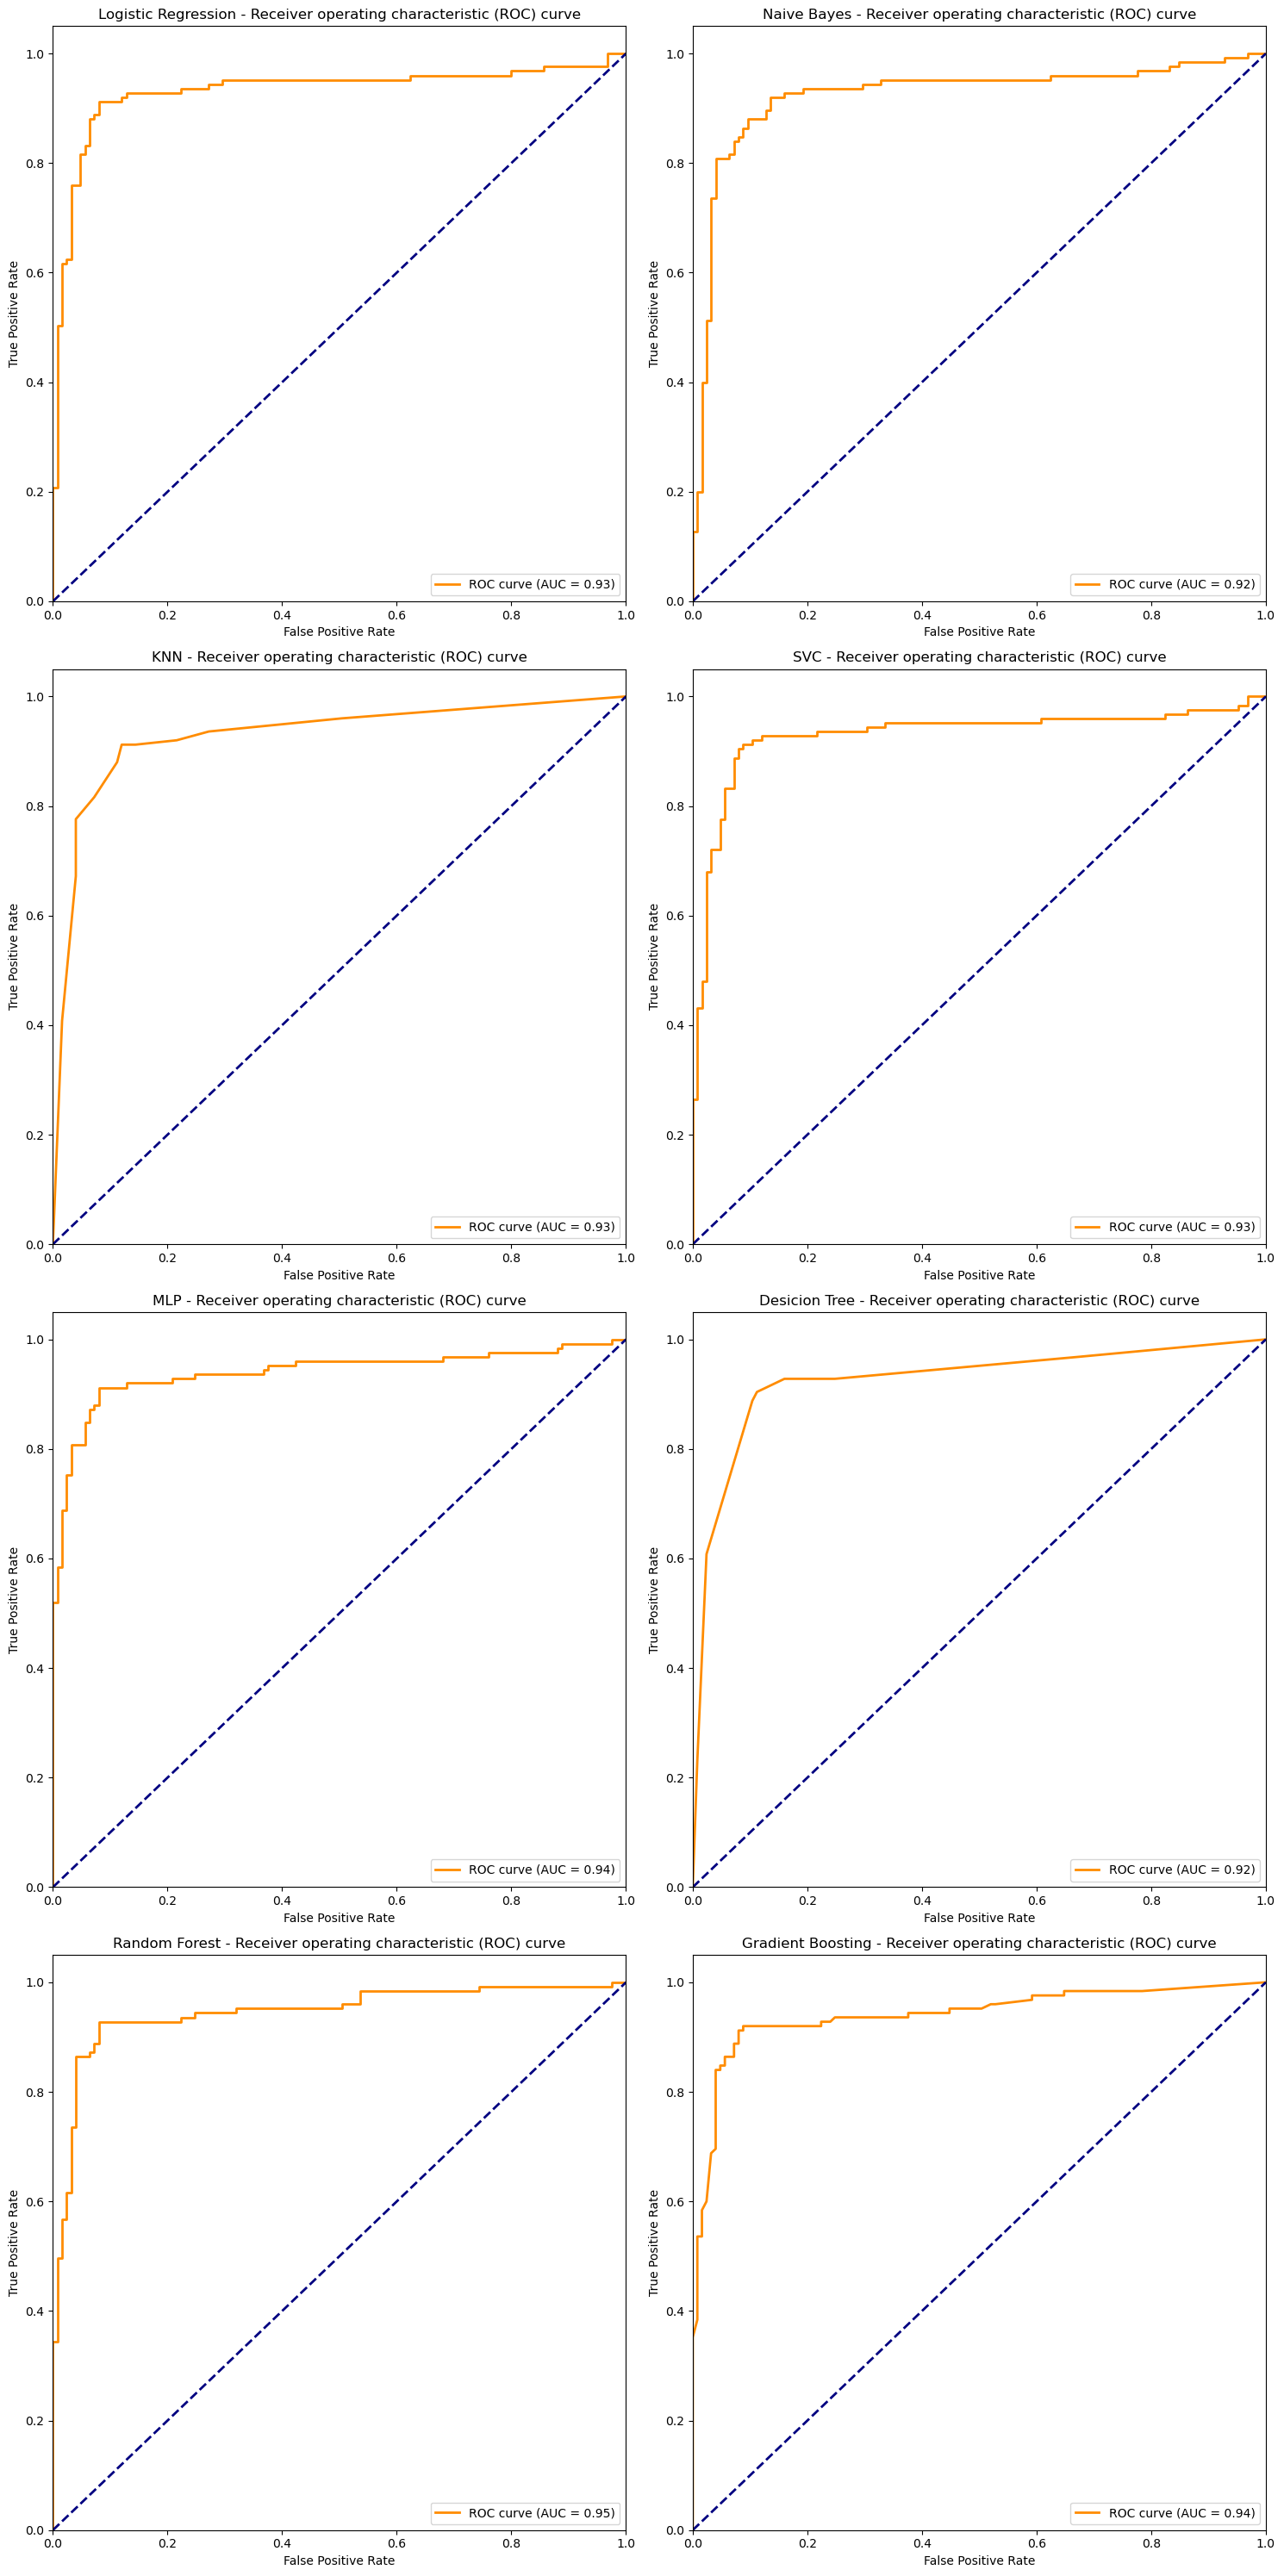

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.880000,0.855431,0.917283,0.884624
1,Naive Bayes,0.814667,0.892888,0.719915,0.793992
2,KNN,0.870667,0.849332,0.903912,0.875069
3,SVC,0.878667,0.852137,0.919986,0.883981
4,MLP,0.876000,0.861068,0.904125,0.880896
5,Desicion Tree,0.868000,0.847393,0.901422,0.872800
6,Random Forest,0.881333,0.859330,0.914580,0.885502
7,Gradient Boosting,0.873333,0.843506,0.919986,0.879364


In [110]:
lr_param = results['Logistic Regression']['best_params']
nb_param = results['Naive Bayes']['best_params']
knn_param = results['KNN']['best_params']
svc_param = results['SVC']['best_params']
svc_param['probability'] = True
mlp_param = results['MLP']['best_params']
dt_param = results['Desicion Tree']['best_params']
rf_param = results['Random Forest']['best_params']
gb_param = results['Gradient Boosting']['best_params']

# Remove 'classifier__' prefix from keys in the parameter dictionaries
lr_param = {k.replace('classifier__', ''): v for k, v in lr_param.items()}
nb_param = {k.replace('classifier__', ''): v for k, v in nb_param.items()}
knn_param = {k.replace('classifier__', ''): v for k, v in knn_param.items()}
svc_param = {k.replace('classifier__', ''): v for k, v in svc_param.items()}
mlp_param = {k.replace('classifier__', ''): v for k, v in mlp_param.items()}
dt_param = {k.replace('classifier__', ''): v for k, v in dt_param.items()}
rf_param = {k.replace('classifier__', ''): v for k, v in rf_param.items()}
gb_param = {k.replace('classifier__', ''): v for k, v in gb_param.items()}

pipelines = [
    Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression(**lr_param, random_state=42))]),
    Pipeline([('scaler', StandardScaler()), ('classifier', GaussianNB(**nb_param))]),
    Pipeline([('scaler', StandardScaler()), ('classifier', KNeighborsClassifier(**knn_param))]),
    Pipeline([('scaler', StandardScaler()), ('classifier', SVC(**svc_param))]),
    Pipeline([('scaler', StandardScaler()), ('classifier', MLPClassifier(**mlp_param, max_iter=1000))]),
    Pipeline([('scaler', StandardScaler()), ('classifier', DecisionTreeClassifier(**dt_param, random_state=42))]),
    Pipeline([('scaler', StandardScaler()), ('classifier', RandomForestClassifier(**rf_param, random_state=42))]),
    Pipeline([('scaler', StandardScaler()), ('classifier', GradientBoostingClassifier(**gb_param, random_state=42))])
]

models_name = list(results.keys())

final_result = {
        'Model': models_name,
        'Accuracy': [],
        'Precision': [],
        'Recall': [],
        'F1': []
    }


n_models = len(pipelines)
n_cols = 2
n_rows = np.ceil(n_models / n_cols).astype(int)

# Create a StratifiedKFold object
skf = StratifiedKFold(n_splits=10)

fig, plots = plt.subplots(n_rows, n_cols, figsize=(15, 30))

for i, pipe in enumerate(pipelines):
    accuracy = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='accuracy').mean()
    precision = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='precision').mean()
    recall = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='recall').mean()
    f1 = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1').mean()
    
    final_result['Accuracy'].append(accuracy)
    final_result['Precision'].append(precision)
    final_result['Recall'].append(recall)
    final_result['F1'].append(f1)

    row = i // n_cols
    col = i % n_cols
    ax = plots[row][col]

    pipe.fit(X_train, y_train)

    y_pred_proba = pipe.predict_proba(X_test)
    y_pred_proba = y_pred_proba[:, 1]
    fpr, tpr, _= roc_curve(y_test, y_pred_proba)
    
    ax.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % auc(fpr, tpr))
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{models_name[i]} - Receiver operating characteristic (ROC) curve')
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

display(pd.DataFrame(final_result))

Penjelasan Tabel:
- Accuracy terbaik dipegang oleh Random Forest di angka 88,1%.
- Precision terbaik dipegang oleh Naive Bayes di angka 89,3%.
- Recall terbaik dipegang oleh SVC dan Gradient Boosting di angka 92%.
- F1 terbaik dipegang oleh Random Forest di angka 88,5%.

Penjelasan Grafik ROC:
- ROC yang tinggi sederhananya berarti bahwa probabilitas 'True Positive' yang dipilih secara acak memang positif. ROC yang tinggi juga berarti algoritma telah melakukan pekerjaan yang baik dalam merangking test data, dengan sebagian besar kasus negatif di satu ujung skala dan kasus positif di ujung lainnya.
- ROC curve tertinggi dengan AuC sebesar 0.95 diraih oleh Random Forest. AuC-ROC mengukur seluruh area dua dimensi di bawah seluruh kurva ROC dari (0,0) hingga (1,1). Model dengan skor AuC yang lebih tinggi umumnya menunjukkan kinerja yang lebih baik, karena hal ini menunjukkan bahwa model tersebut dapat secara efektif membedakan kelas positif dan negatif. 

Sehingga, dapat disimpulkan bahwa Random Forest menunjukkan kinerja yang paling baik.

## Visualisasi

### Train

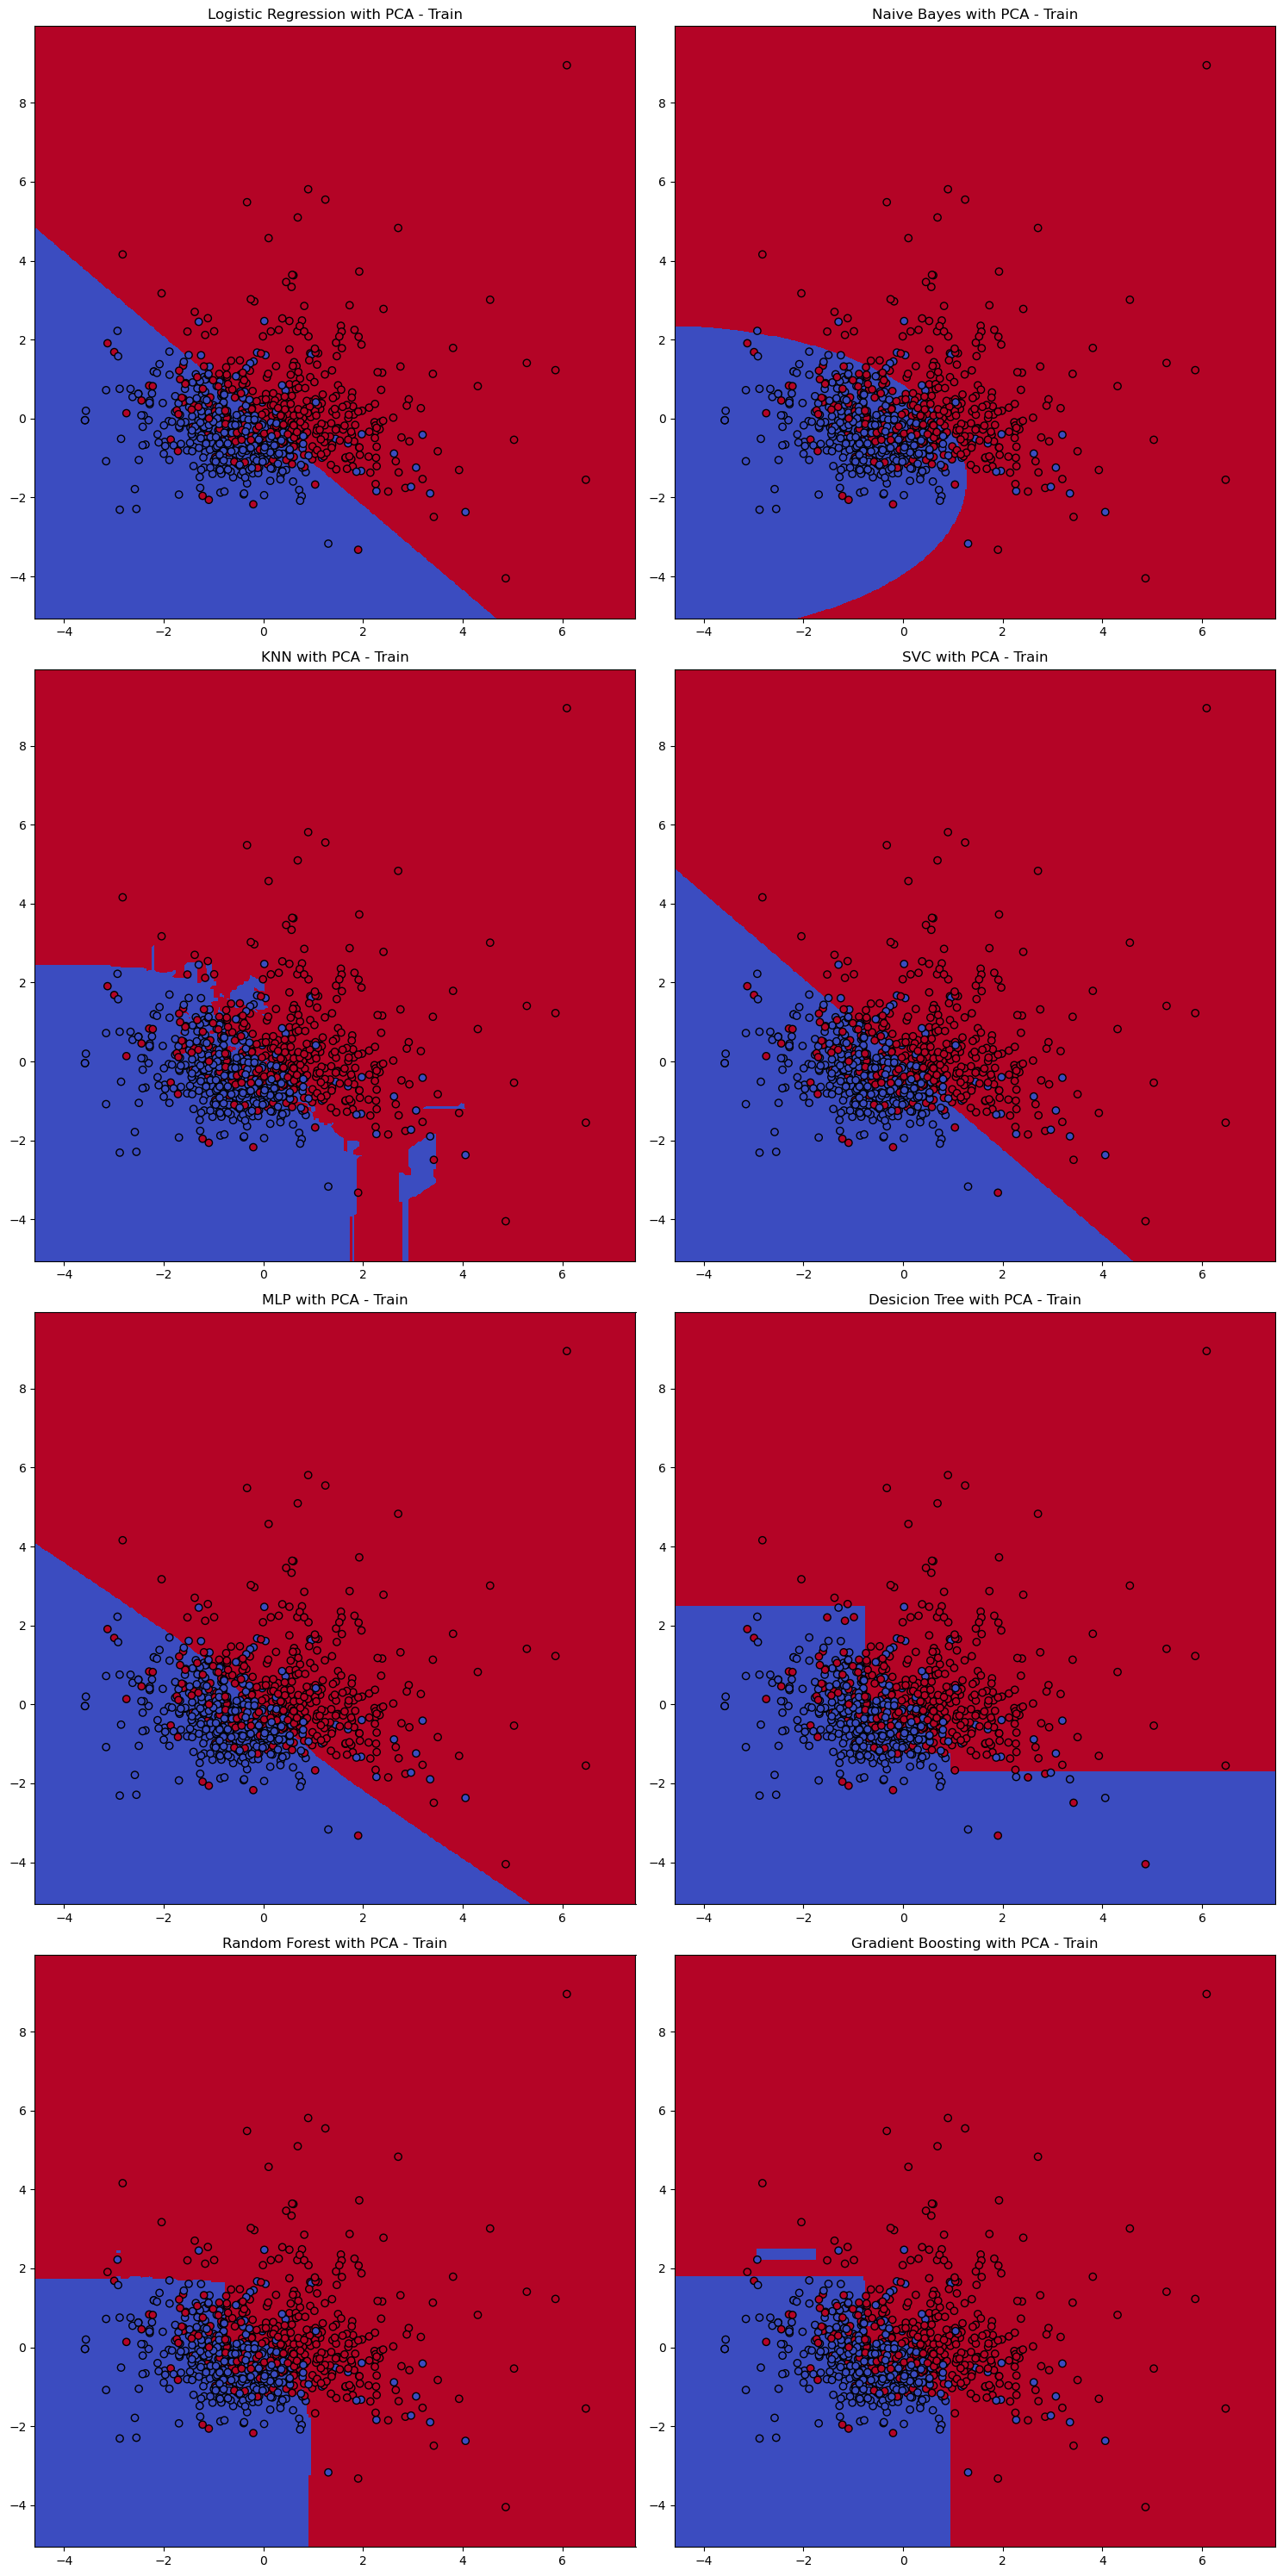

In [111]:
# Reduce the dimension of the training data to two
pca = PCA(n_components=2)

# Create a figure with four subplots
fig, plots = plt.subplots(n_rows, n_cols, figsize=(15, 30))

for i, model in enumerate(pipelines):
    pipe = Pipeline([('scaler', StandardScaler()), ('pca', pca)])

    X_train_pca = pipe.fit_transform(X_train)
    X_test_pca = pipe.fit_transform(X_test)

    row = i // n_cols
    col = i % n_cols
    ax = plots[row][col]

    model.fit(X_train_pca, y_train)

    # Create a meshgrid for the contour plot of X_train_pca
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
    )

    # Predict the class labels for the points in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Reshape the predictions to have the same shape as xx and yy
    Z = Z.reshape(xx.shape)

    ax.pcolormesh(xx, yy, Z, cmap='coolwarm')
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train.to_numpy(), edgecolors='black', cmap='coolwarm')
    ax.set_title(f'{models_name[i]} with PCA - Train')   

plt.tight_layout()
plt.show()

### Test

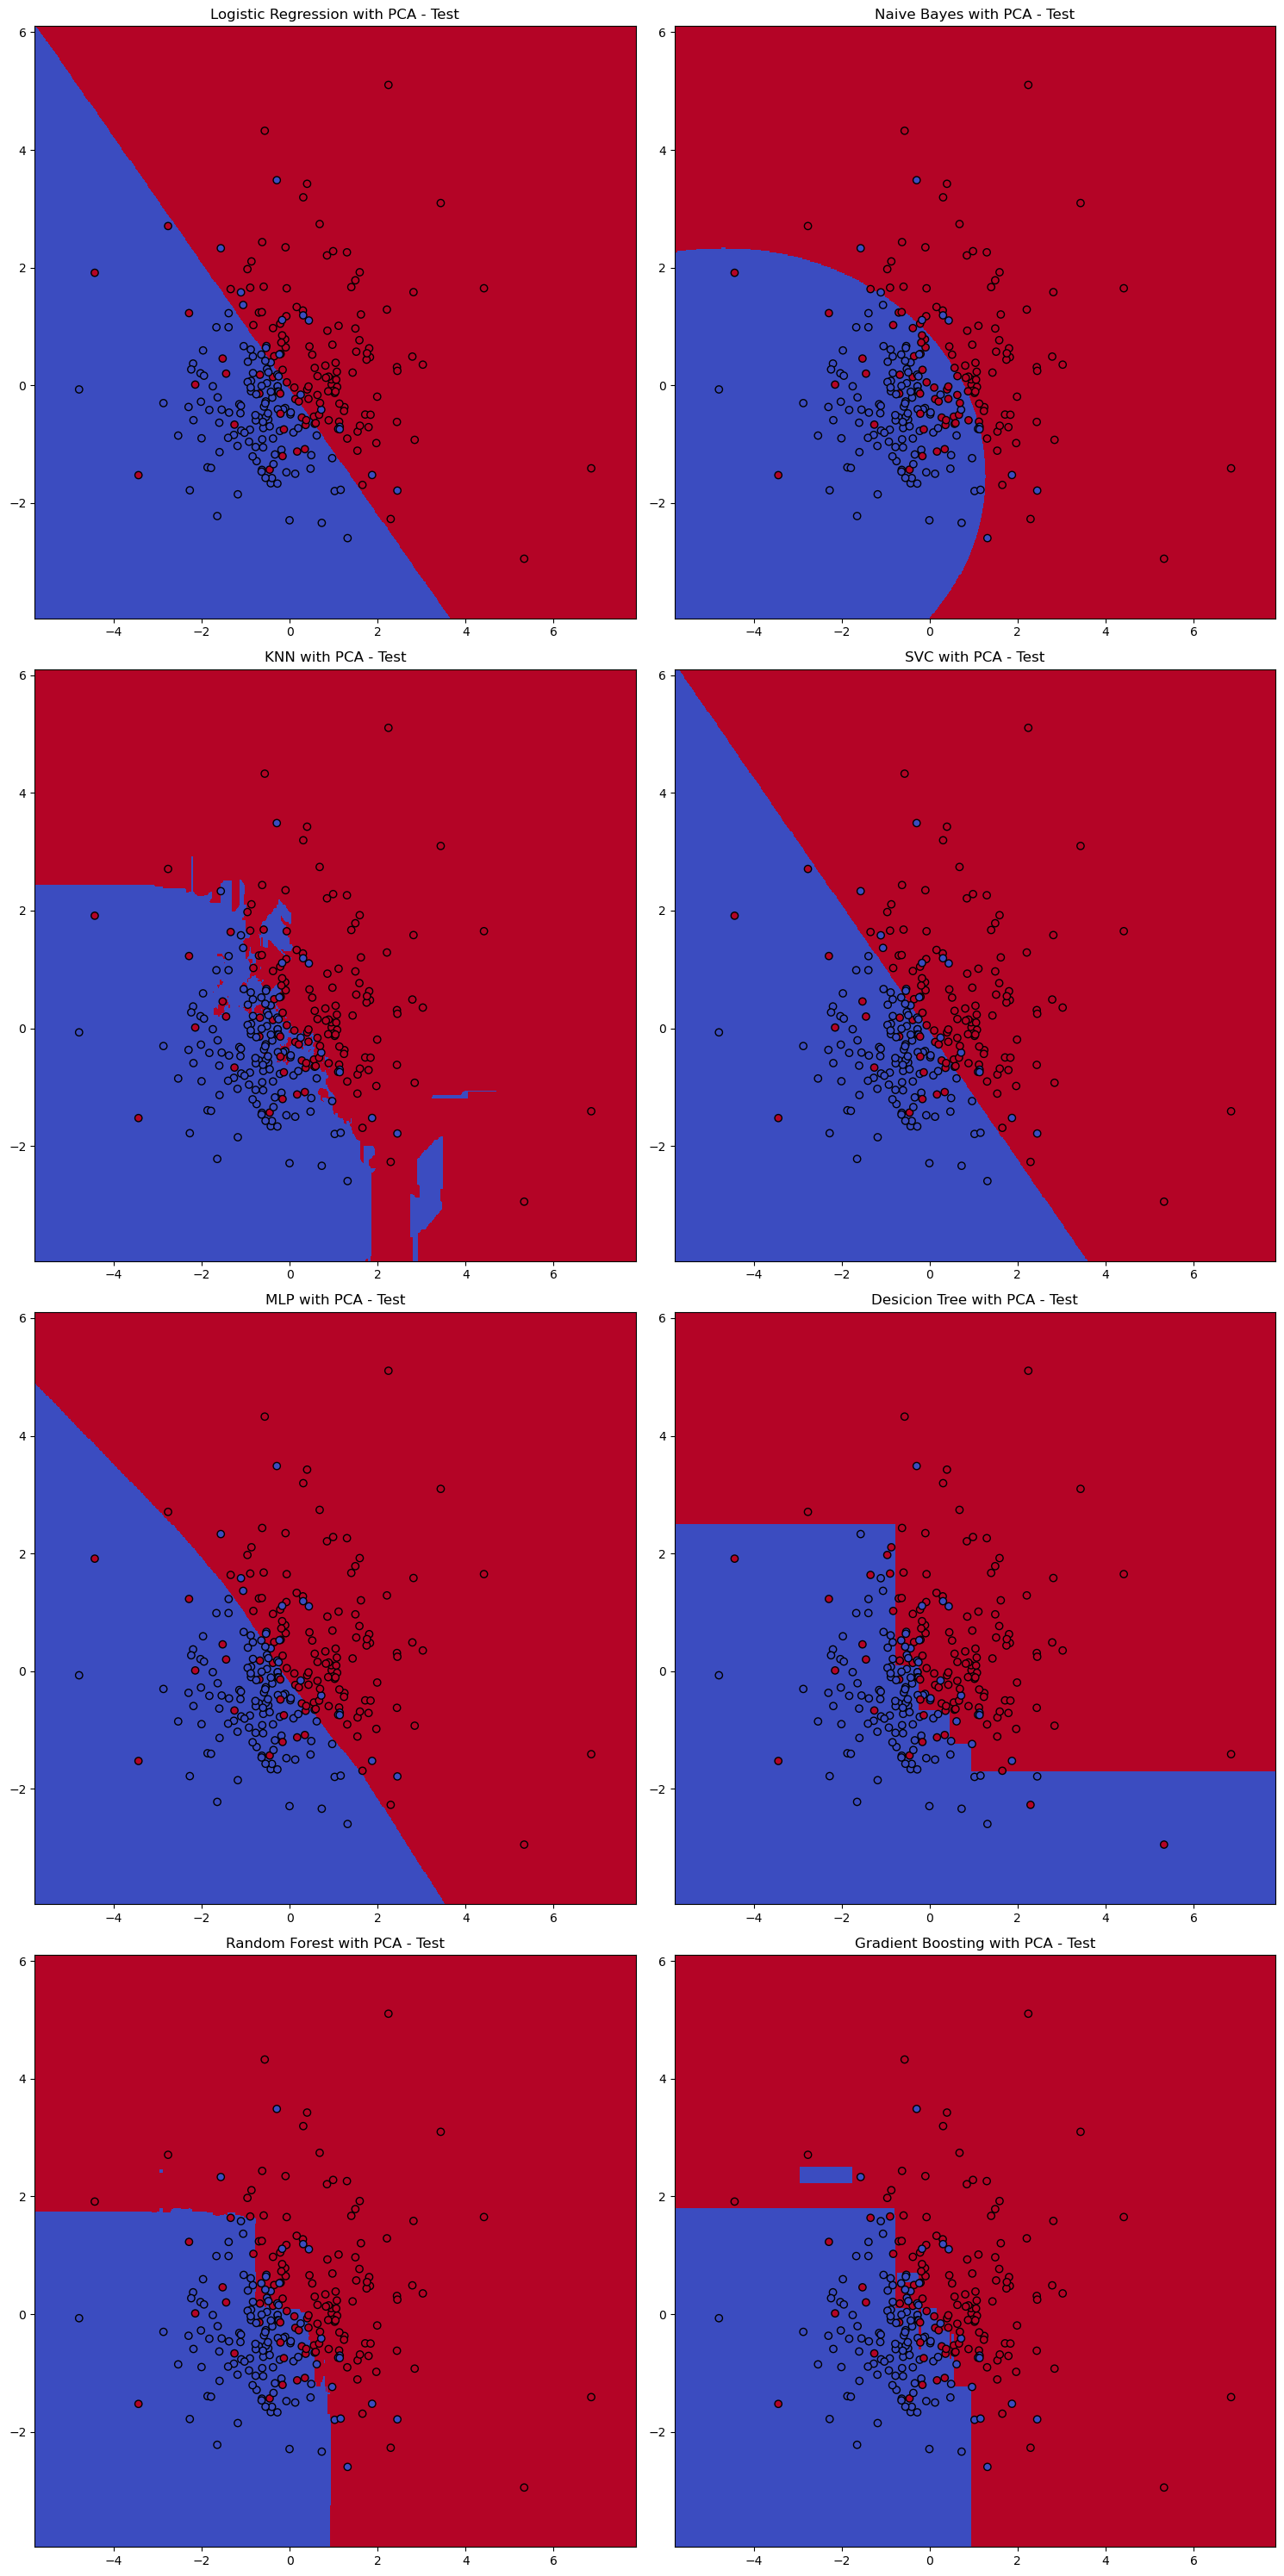

In [112]:
# Reduce the dimension of the training data to two
pca = PCA(n_components=2)

n_models = len(pipelines)
n_cols = 2
n_rows = np.ceil(n_models / n_cols).astype(int)

# Create a figure with four subplots
fig, plots = plt.subplots(n_rows, n_cols, figsize=(15, 30))

for i, model in enumerate(pipelines):
    pipe = Pipeline([('scaler', StandardScaler()), ('pca', pca)])

    X_train_pca = pipe.fit_transform(X_train)
    X_test_pca = pipe.fit_transform(X_test)

    row = i // n_cols
    col = i % n_cols
    ax = plots[row][col]

    model.fit(X_train_pca, y_train)

    # Create a meshgrid for the contour plot of X_train_pca
    x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
    y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
    )

    # Predict the class labels for the points in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Reshape the predictions to have the same shape as xx and yy
    Z = Z.reshape(xx.shape)

    ax.pcolormesh(xx, yy, Z, cmap='coolwarm')
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test.to_numpy(), edgecolors='black', cmap='coolwarm')
    ax.set_title(f'{models_name[i]} with PCA - Test')   

plt.tight_layout()
plt.show()

### Kesimpulan Visualisasi
- Melalui visualisasi desicion boundary dari train dan test, ketika membandingakan setiap titik dari test dengan decision boundary dari train, kami mendapati bahwa mayoritas titik-titik sudah berada dalam boundary yang sesuai. Namun, masih terdapat beberapa titik yang belum sesuai dengan classnya.
- Diantara model-model terebut, KNN, Decision Tree, Random Forest, dan Gradient Boosting cenderung overfitting terhadap data. Hal ini dapat dilihat dari garis boundary yang memiliki banyak patahan.

## Kesimpulan Proyek

Dalam proyek ini, kami telah berhasil melatih model Logistic Regression, Naive Bayes, KNN, SVC, MLP, Decision Tree, Random Forest, dan Gradient Boosting agar mampu mengklasifikasi berbagai tipe bintang ke dalam kelas Giants dan Dwarfts. Menurut tabel evaluasi model, diantara berbagai model tersebut, Random Forest memiliki tingkat akurasi paling tinggi yaitu sebesar 88,3%. Precision terbaik dipegang oleh Naive Bayes di angka 88,9%. Recall terbaik dipegang oleh KNN di angka 92,8%. F1 terbaik dipegang oleh Random Forest di angka 88,7%.

Dari grafik ROC, ROC curve tertinggi dengan AuC sebesar 95% diraih oleh Random Forest. Model dengan skor AuC yang lebih tinggi umumnya menunjukkan kinerja yang lebih baik, karena hal ini menunjukkan bahwa model tersebut dapat secara efektif membedakan kelas positif dan negatif.

Sehingga, dapat disimpulkan bahwa Random Forest menunjukkan kinerja yang paling baik.